For WavLM, I used the whole eval and train part for VGGish in my first round caused 0.99 train and 0.59 test roc auc overfitting also cheating in comparison to other SSL models as they used only 7000 training data, so in my second round I ran the codes using the specific 7000 samples same as what we used for HuBERT and XLSR !!!! NO difference , overfitted , 0.5867 after subseting the 7000 samples. 

In [2]:
import pandas as pd

In [3]:
pd

<module 'pandas' from '/umbc/rs/iharp/users/zkhanja1/tensorflow_env/lib/python3.13/site-packages/pandas/__init__.py'>

In [4]:
import tensorflow as tf

2025-11-18 10:45:57.869481: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-18 10:45:57.924038: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-18 10:46:00.014700: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
pd

<module 'pandas' from '/umbc/rs/iharp/users/zkhanja1/tensorflow_env/lib/python3.13/site-packages/pandas/__init__.py'>

In [ ]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 27.3 MB/s eta 0:00:00a 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 37.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install -U scikit-learn scipy

  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.5.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 56.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 92.4 MB/s eta 0:00:00:00:0100:01
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
Using cached threadpoolctl-3.5.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install librosa

  Using cached librosa-0.10.2.post1-py3-none-any.whl.metadata (8.6 kB)
  Using cached audioread-3.0.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached soundfile-0.13.1-py2.py3-none-any.whl.metadata (16 kB)
  Using cached pooch-1.8.2-py3-none-any.whl.metadata (10 kB)
  Using cached lazy_loader-0.4-py3-none-any.whl.metadata (7.6 kB)
  Using cached pycparser-2.22-py3-none-any.whl.metadata (943 bytes)
Using cached librosa-0.10.2.post1-py3-none-any.whl (260 kB)
Using cached audioread-3.0.1-py3-none-any.whl (23 kB)
Using cached lazy_loader-0.4-py3-none-any.whl (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 84.1 MB/s eta 0:00:00
Using cached pooch-1.8.2-py3-none-any.whl (64 kB)
Using cached soundfile-0.13.1-py2.py3-none-any.whl (25 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 95.0 MB/s eta 0:00:00:00:0100:01
Using cached pycparser-2.22-py3-none-any.whl (117 kB)
Note: you may need to restart the kernel to use updated packages.


In [33]:
pip install resampy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 14.3 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [36]:
pip install tf_slim

Note: you may need to restart the kernel to use updated packages.


In [5]:
from tensorflow.keras.models import Model
from tensorflow.keras import Input
from tensorflow.keras.layers import concatenate, Permute, Reshape
import os

In [6]:
import math
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential

In [7]:
#from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import LSTM,TimeDistributed
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import BatchNormalization
from keras.layers import MaxPooling2D
from keras.layers import BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import StratifiedKFold
import numpy as np
import sklearn.metrics as metrics

In [9]:
import pandas as pd
import math
import numpy as np
#from numpy.lib.function_base import average
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
import tensorflow
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras import models, layers
import tensorflow as tf
from matplotlib.pyplot import specgram
import glob

In [10]:
from sklearn.metrics import confusion_matrix
import IPython.display as ipd  # To play sound in the notebook
from sklearn.model_selection import train_test_split
import tensorflow.keras as keras
import sys
import warnings
# ignore warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
import json

from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

import pickle
import joblib
from tensorflow.keras import models, layers
import tensorflow as tf

In [11]:
pwd

'/umbc/rs/iharp/users/zkhanja1/asvspoof5_codes'

In [17]:
!wget https://storage.googleapis.com/audioset/vggish_model.ckpt
!wget https://storage.googleapis.com/audioset/vggish_pca_params.npz

--2025-11-10 07:28:26--  https://storage.googleapis.com/audioset/vggish_model.ckpt
Resolving storage.googleapis.com (storage.googleapis.com)... 172.253.62.207, 142.251.167.207, 172.253.122.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.253.62.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 291108469 (278M) [application/octet-stream]
Saving to: ‘vggish_model.ckpt’

vggish_model.ckpt   100%[===================>] 277.62M  84.0MB/s    in 3.3s    

2025-11-10 07:28:31 (84.0 MB/s) - ‘vggish_model.ckpt’ saved [291108469/291108469]

--2025-11-10 07:28:31--  https://storage.googleapis.com/audioset/vggish_pca_params.npz
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.163.207, 172.253.115.207, 142.251.167.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.163.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 73020 (71K) [application/octet-stream]
Saving to: ‘vggis

In [21]:
pwd

'/umbc/rs/iharp/users/zkhanja1/asvspoof5_codes'

In [25]:
!git clone https://github.com/tensorflow/models.git

Cloning into 'models'...
remote: Enumerating objects: 102855, done.
remote: Counting objects: 100% (179/179), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 102855 (delta 136), reused 80 (delta 80), pack-reused 102676 (from 4)
Receiving objects: 100% (102855/102855), 642.86 MiB | 64.23 MiB/s, done.
Resolving deltas: 100% (74291/74291), done.
Updating files: 100% (3960/3960), done.


In [30]:
pwd

'/umbc/rs/iharp/users/zkhanja1/asvspoof5_codes'

In [31]:
cd /umbc/rs/iharp/users/zkhanja1/asvspoof5_codes/models/research/audioset/vggish/

/umbc/rs/iharp/users/zkhanja1/asvspoof5_codes/models/research/audioset/vggish


In [34]:
import vggish_input

In [37]:

import vggish_params
import vggish_postprocess
import vggish_slim

In [38]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


In [ ]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!nvidia-smi

Sat Mar 29 10:24:09 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 530.30.02              Driver Version: 530.30.02    CUDA Version: 12.1     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                  Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf            Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Quadro RTX 6000                 On | 00000000:3D:00.0 Off |                  Off |
| 33%   22C    P8               14W / 250W|  23553MiB / 24576MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
!pip3 list | grep tensorflow

tensorflow                         2.13.1
tensorflow-estimator               2.13.0
tensorflow-io-gcs-filesystem       0.34.0


In [ ]:
import tensorflow as tf

# Get all GPUs
gpus = tf.config.list_physical_devices('GPU')

if len(gpus) > 1:
    # Only use GPU 0, hide GPU 1
    tf.config.experimental.set_visible_devices(gpus[0], 'GPU')

print("Available GPUs after filtering:", tf.config.list_physical_devices('GPU'))


Available GPUs after filtering: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
print(tf.__version__)

2.18.0


In [ ]:
gpus = tf.config.list_physical_devices('GPU')
print("Available GPUs:", gpus)

if gpus:
    try:
        tf.config.set_visible_devices(gpus[0], 'GPU')
        tf.config.experimental.set_memory_growth(gpus[0], True)  # Avoid full memory allocation
        print("Using GPU:", gpus[0])
    except RuntimeError as e:
        print(e)


Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
tf.debugging.set_log_device_placement(True)

In [ ]:
tf

<module 'tensorflow' from '/home/zkhanja1/.conda/envs/myenv/lib/python3.10/site-packages/tensorflow/__init__.py'>

In [11]:
import tensorflow as tf
import librosa
import os
import vggish_input
import vggish_params

ModuleNotFoundError: No module named 'vggish_input'

In [40]:
import vggish_slim

In [ ]:
/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac_T_aa/flac_T

In [42]:
cd /umbc/rs/iharp/users/zkhanja1/asvspoof5_codes

/umbc/rs/iharp/users/zkhanja1/asvspoof5_codes


In [43]:

tf.compat.v1.disable_eager_execution()
# Enable logging of device placement
tf.debugging.set_log_device_placement(True)

# Define the folder containing audio files
audio_folder = '/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac_T_aa/flac_T'

# Get a list of all .wav audio files
audio_files = [f for f in os.listdir(audio_folder) if f.endswith('.flac')]

# Initialize lists to store extracted features, paths, and file names
vggish_features_list = []
paths_list = []
file_names_list = []

# Load the VGGish model
sess = tf.compat.v1.Session()
with sess.as_default():
    vggish_slim.define_vggish_slim()
    vggish_saver = tf.compat.v1.train.Saver()
    vggish_saver.restore(sess, "vggish_model.ckpt")  # Ensure this file exists in your working directory

# Get VGGish input and output tensors
features_tensor = sess.graph.get_tensor_by_name(vggish_params.INPUT_TENSOR_NAME)
embedding_tensor = sess.graph.get_tensor_by_name(vggish_params.OUTPUT_TENSOR_NAME)

# Process each audio file
for audio_file in audio_files:
    audio_path = os.path.join(audio_folder, audio_file)

    # Convert .wav file into VGGish-compatible input
    example_wav_data = vggish_input.wavfile_to_examples(audio_path)

    # Run the model and extract embeddings
    vggish_features = sess.run(embedding_tensor, feed_dict={features_tensor: example_wav_data})

    # Store results
    vggish_features_list.append(vggish_features)
    paths_list.append(audio_path)
    file_names_list.append(audio_file)


# Create a DataFrame with file metadata
df = pd.DataFrame({'Path': paths_list, 'FileName': file_names_list})



Device mapping:
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: NVIDIA L40S, pci bus id: 0000:4a:00.0, compute capability: 8.9



I0000 00:00:1762778503.996224  957158 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43490 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:4a:00.0, compute capability: 8.9


INFO:tensorflow:Restoring parameters from vggish_model.ckpt
vggish/Reshape: (Reshape): /job:localhost/replica:0/task:0/device:GPU:0
vggish/conv1/weights/Initializer/truncated_normal/TruncatedNormal: (TruncatedNormal): /job:localhost/replica:0/task:0/device:GPU:0
vggish/conv1/weights/Initializer/truncated_normal/mul: (Mul): /job:localhost/replica:0/task:0/device:GPU:0
vggish/conv1/weights/Initializer/truncated_normal: (AddV2): /job:localhost/replica:0/task:0/device:GPU:0
vggish/conv1/weights/IsInitialized/VarIsInitializedOp: (VarIsInitializedOp): /job:localhost/replica:0/task:0/device:GPU:0
vggish/conv1/weights/Assign: (AssignVariableOp): /job:localhost/replica:0/task:0/device:GPU:0
vggish/conv1/weights/Read/ReadVariableOp: (ReadVariableOp): /job:localhost/replica:0/task:0/device:GPU:0
vggish/conv1/biases/IsInitialized/VarIsInitializedOp: (VarIsInitializedOp): /job:localhost/replica:0/task:0/device:GPU:0
vggish/conv1/biases/Assign: (AssignVariableOp): /job:localhost/replica:0/task:0/dev

I0000 00:00:1762778504.370046  957158 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2025-11-10 07:41:44.375777: I tensorflow/core/common_runtime/placer.cc:162] vggish/Reshape: (Reshape): /job:localhost/replica:0/task:0/device:GPU:0
2025-11-10 07:41:44.375819: I tensorflow/core/common_runtime/placer.cc:162] vggish/conv1/weights/Initializer/truncated_normal/TruncatedNormal: (TruncatedNormal): /job:localhost/replica:0/task:0/device:GPU:0
2025-11-10 07:41:44.375834: I tensorflow/core/common_runtime/placer.cc:162] vggish/conv1/weights/Initializer/truncated_normal/mul: (Mul): /job:localhost/replica:0/task:0/device:GPU:0
2025-11-10 07:41:44.375845: I tensorflow/core/common_runtime/placer.cc:162] vggish/conv1/weights/Initializer/truncated_normal: (AddV2): /job:localhost/replica:0/task:0/device:GPU:0
2025-11-10 07:41:44.375855: I tensorflow/core/common_runtime/placer.cc:162] vggish/conv1/weights/IsInitialized/VarIsInitializedOp: (VarIsInitializedOp): /job:localho

In [44]:
# Pad shorter clips with zeros to match the maximum number of frames
max_frames = max(features.shape[0] for features in vggish_features_list)
vggish_features_list_padded = [np.pad(features, ((0, max_frames - features.shape[0]), (0, 0)), mode='constant') for features in vggish_features_list]
vggish_features_array = np.stack(vggish_features_list_padded, axis=0)


In [47]:
len(vggish_features_array)

36500

In [48]:
vggish_features_array.shape

(36500, 30, 128)

#Pad shorter clips with zeros to match the maximum number of frames
max_frames = max(features.shape[0] for features in vggish_features_list)
vggish_features_list_padded = [np.pad(features, ((0, max_frames - features.shape[0]), (0, 0)), mode='constant') for features in vggish_features_list]
vggish_features_array = np.stack(vggish_features_list_padded, axis=0)
#Save extracted features and metadata
np.save('/umbc/rs/iharp/users/zkhanja1/asvspoof5_codes/asvspoof5_vggish_features_array_train.npy', vggish_features_array)
#df.to_csv('/nfs/rs/vjaneja/users/zkhanja1/audio_file_info_train.csv', index=False)

print("Feature extraction complete. Files saved.")

In [50]:
len(vggish_features_array)
# Save extracted features and metadata
np.save('asvspoof5_vggish_features_array_train2.npy', vggish_features_array)
#df.to_csv('/nfs/rs/vjaneja/users/zkhanja1/audio_file_info_train.csv', index=False)

print("Feature extraction complete. Files saved.")

Feature extraction complete. Files saved.


In [29]:
import numpy as np

# Load the saved .npy file
vggish_features_array = np.load('asvspoof5_vggish_features_array_train2.npy')

print("Loaded features shape:", vggish_features_array.shape)

Loaded features shape: (36500, 30, 128)


In [20]:
vggish_features_array_eval = np.load('asvspoofvggish_features_array_eval.npy')

print("Loaded features shape:", vggish_features_array_eval.shape)

Loaded features shape: (68188, 19, 128)


In [30]:
vggish_features_array_train = vggish_features_array

In [51]:
df.to_csv("asvspoof5_train_fTa_audio_file_names.csv", index=False)

In [12]:
df_train = pd.read_csv("asvspoof5_train_fTa_audio_file_names.csv")

In [13]:
df_train

,Path,FileName
0,/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac...,T_0000023804.flac
1,/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac...,T_0000009556.flac
2,/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac...,T_0000009135.flac
3,/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac...,T_0000024330.flac
4,/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac...,T_0000008809.flac
...,...,...
36495,/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac...,T_0000015302.flac
36496,/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac...,T_0000016337.flac
36497,/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac...,T_0000009424.flac
36498,/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac...,T_0000013754.flac


In [16]:
df_test = pd.read_csv("asvspoof5_audio_file_info_eval.csv")

In [54]:
# ✅ Reset default graph before defining model
tf.compat.v1.reset_default_graph()

In [55]:
audio_folder = '/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac_E_eval'
tf.compat.v1.disable_eager_execution()
# Enable logging of device placement
tf.debugging.set_log_device_placement(True)

# Get a list of all .wav audio files
audio_files = [f for f in os.listdir(audio_folder) if f.endswith('.flac')]

# Initialize lists to store extracted features, paths, and file names
vggish_features_list = []
paths_list = []
file_names_list = []

# Load the VGGish model
sess = tf.compat.v1.Session()
with sess.as_default():
    vggish_slim.define_vggish_slim()
    vggish_saver = tf.compat.v1.train.Saver()
    vggish_saver.restore(sess, "vggish_model.ckpt")  # Ensure this file exists in your working directory

# Get VGGish input and output tensors
features_tensor = sess.graph.get_tensor_by_name(vggish_params.INPUT_TENSOR_NAME)
embedding_tensor = sess.graph.get_tensor_by_name(vggish_params.OUTPUT_TENSOR_NAME)

# Process each audio file
for audio_file in audio_files:
    audio_path = os.path.join(audio_folder, audio_file)

    # Convert .wav file into VGGish-compatible input
    example_wav_data = vggish_input.wavfile_to_examples(audio_path)

    # Run the model and extract embeddings
    vggish_features = sess.run(embedding_tensor, feed_dict={features_tensor: example_wav_data})

    # Store results
    vggish_features_list.append(vggish_features)
    paths_list.append(audio_path)
    file_names_list.append(audio_file)

# Create a DataFrame with file metadata
df = pd.DataFrame({'Path': paths_list, 'FileName': file_names_list})



Device mapping:
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: NVIDIA L40S, pci bus id: 0000:4a:00.0, compute capability: 8.9

INFO:tensorflow:Restoring parameters from vggish_model.ckpt


I0000 00:00:1762794065.565499  957158 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43490 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:4a:00.0, compute capability: 8.9
2025-11-10 12:01:05.652973: I tensorflow/core/common_runtime/placer.cc:162] vggish/Reshape: (Reshape): /job:localhost/replica:0/task:0/device:GPU:0
2025-11-10 12:01:05.653021: I tensorflow/core/common_runtime/placer.cc:162] vggish/conv1/weights/Initializer/truncated_normal/TruncatedNormal: (TruncatedNormal): /job:localhost/replica:0/task:0/device:GPU:0
2025-11-10 12:01:05.653037: I tensorflow/core/common_runtime/placer.cc:162] vggish/conv1/weights/Initializer/truncated_normal/mul: (Mul): /job:localhost/replica:0/task:0/device:GPU:0
2025-11-10 12:01:05.653048: I tensorflow/core/common_runtime/placer.cc:162] vggish/conv1/weights/Initializer/truncated_normal: (AddV2): /job:localhost/replica:0/task:0/device:GPU:0
2025-11-10 12:01:05.653057: I tensorflow/core/common_runt

vggish/Reshape: (Reshape): /job:localhost/replica:0/task:0/device:GPU:0
vggish/conv1/weights/Initializer/truncated_normal/TruncatedNormal: (TruncatedNormal): /job:localhost/replica:0/task:0/device:GPU:0
vggish/conv1/weights/Initializer/truncated_normal/mul: (Mul): /job:localhost/replica:0/task:0/device:GPU:0
vggish/conv1/weights/Initializer/truncated_normal: (AddV2): /job:localhost/replica:0/task:0/device:GPU:0
vggish/conv1/weights/IsInitialized/VarIsInitializedOp: (VarIsInitializedOp): /job:localhost/replica:0/task:0/device:GPU:0
vggish/conv1/weights/Assign: (AssignVariableOp): /job:localhost/replica:0/task:0/device:GPU:0
vggish/conv1/weights/Read/ReadVariableOp: (ReadVariableOp): /job:localhost/replica:0/task:0/device:GPU:0
vggish/conv1/biases/IsInitialized/VarIsInitializedOp: (VarIsInitializedOp): /job:localhost/replica:0/task:0/device:GPU:0
vggish/conv1/biases/Assign: (AssignVariableOp): /job:localhost/replica:0/task:0/device:GPU:0
vggish/conv1/biases/Read/ReadVariableOp: (ReadVari

In [28]:
X_train.shape

NameError: name 'X_train' is not defined

In [56]:
# Pad shorter clips with zeros to match the maximum number of frames
max_frames = max(features.shape[0] for features in vggish_features_list)
vggish_features_list_padded = [np.pad(features, ((0, max_frames - features.shape[0]), (0, 0)), mode='constant') for features in vggish_features_list]
vggish_features_array = np.stack(vggish_features_list_padded, axis=0)
# Save extracted features and metadata
#np.save('/nfs/rs/vjaneja/users/zkhanja1/vggish_features_array_dev2.npy', vggish_features_array)
#df.to_csv('/nfs/rs/vjaneja/users/zkhanja1/audio_file_info_train.csv', index=False)

print("Feature extraction complete. Files saved.")

FileNotFoundError: [Errno 2] No such file or directory: '/nfs/rs/vjaneja/users/zkhanja1/vggish_features_array_dev2.npy'

In [23]:
len(vggish_features_array_eval)

68188

In [59]:
len(vggish_features_array)
# Save extracted features and metadata
np.save('asvspoofvggish_features_array_eval.npy', vggish_features_array)
df.to_csv('asvspoof5_audio_file_info_eval.csv', index=False)

print("Feature extraction complete. Files saved.")

Feature extraction complete. Files saved.


In [22]:
#how many audio clips were less than 11

# Count nonzero frames (assuming zero-padding)
nonzero_counts = np.count_nonzero(
    np.any(vggish_features_array_eval != 0, axis=2),
    axis=1
)

num_under_11 = np.sum(nonzero_counts < 11)
print("Number of clips with < 11 frames:", num_under_11)


Number of clips with < 11 frames: 67319


In [24]:
67319/68188

0.9872558221387927

98 percent are less than 11 frame like the original ALiRAS method

In [31]:
nonzero_counts = np.count_nonzero(
    np.any(vggish_features_array != 0, axis=2),
    axis=1
)

num_under_11 = np.sum(nonzero_counts < 11)
print("Number of clips with in the training set < 11 frames:", num_under_11)

Number of clips with in the training set < 11 frames: 13290


In [32]:
len(vggish_features_array)

36500

In [33]:
13290/36500

0.3641095890410959

In [37]:
num_under_11 = np.sum(nonzero_counts < 13)
print("Number of clips with in the training set < 11 frames:", num_under_11)

Number of clips with in the training set < 11 frames: 22155


In [38]:
22155/36500

0.606986301369863

I turncuated them to 11 frames

In [39]:
X_test = vggish_features_array_eval[:, :11, :]

In [40]:
X_train = vggish_features_array[:, :11, :]

# Training Data for fake vs real - VGGish

In [42]:
df_eval = pd.read_csv('asvspoof5_audio_file_info_eval.csv')

In [44]:
df_train = pd.read_csv('asvspoof5_train_vggish_Ta_audio_file_names.csv')

In [45]:
df_train

,Path,FileName
0,/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac...,T_0000023804.flac
1,/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac...,T_0000009556.flac
2,/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac...,T_0000009135.flac
3,/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac...,T_0000024330.flac
4,/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac...,T_0000008809.flac
...,...,...
36495,/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac...,T_0000015302.flac
36496,/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac...,T_0000016337.flac
36497,/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac...,T_0000009424.flac
36498,/umbc/rs/vjaneja/users/zkhanja1/asvspoof5/flac...,T_0000013754.flac


In [46]:
Df_train_with_labels = pd.read_csv('/umbc/rs/iharp/users/zkhanja1/asvspoof5/protocols/ASVspoof5.train.tsv', sep=' ', header=None)

In [47]:
df_metadata = Df_train_with_labels

In [48]:
df_metadata

,0,1,2,3,4,5,6,7,8
0,T_0000000000.flac,F,-,-,-,AC3,A05,spoof,-
1,T_0000000001.flac,M,-,-,-,AC3,A07,spoof,-
2,T_0000000002.flac,M,-,-,-,AC2,A04,spoof,-
3,T_0000000003.flac,M,-,-,-,AC2,A08,spoof,-
4,T_0000000004.flac,M,-,-,-,AC2,A05,spoof,-
...,...,...,...,...,...,...,...,...,...
182352,T_0000182352.flac,F,-,-,-,AC2,A03,spoof,-
182353,T_0000182353.flac,M,-,-,-,AC2,A05,spoof,-
182354,T_0000182354.flac,M,-,-,-,AC3,A02,spoof,-
182355,T_0000182355.flac,M,-,-,-,-,bonafide,bonafide,-


In [49]:
df_metadata.rename(columns={0: 'FileName', 7: 'Label'}, inplace=True)



In [50]:
df_metadata

,FileName,1,2,3,4,5,6,Label,8
0,T_0000000000.flac,F,-,-,-,AC3,A05,spoof,-
1,T_0000000001.flac,M,-,-,-,AC3,A07,spoof,-
2,T_0000000002.flac,M,-,-,-,AC2,A04,spoof,-
3,T_0000000003.flac,M,-,-,-,AC2,A08,spoof,-
4,T_0000000004.flac,M,-,-,-,AC2,A05,spoof,-
...,...,...,...,...,...,...,...,...,...
182352,T_0000182352.flac,F,-,-,-,AC2,A03,spoof,-
182353,T_0000182353.flac,M,-,-,-,AC2,A05,spoof,-
182354,T_0000182354.flac,M,-,-,-,AC3,A02,spoof,-
182355,T_0000182355.flac,M,-,-,-,-,bonafide,bonafide,-


In [51]:
df_subset = df_metadata[['FileName', 'Label']]

In [52]:
 Df_eval_all_parts_with_labels = pd.read_csv('/umbc/rs/iharp/users/zkhanja1/asvspoof5/protocols/ASVspoof5.eval.track_1.tsv', sep=' ', header=None)

In [53]:
df_all = Df_eval_all_parts_with_labels

In [54]:
df_all

,0,1,2,3,4,5,6,7,8,9
0,E_1607,E_0009538969,M,C05,2,E_0009486171,AC1,A26,spoof,-
1,E_3614,E_0009249178,F,C11,4,E_0006756001,AC1,A27,spoof,-
2,E_2192,E_0004993854,F,-,0,-,-,bonafide,bonafide,-
3,E_0237,E_0006624752,M,C01,1,E_0007675046,AC2,A25,spoof,-
4,E_0884,E_0007708293,F,C07,5,E_0006994972,AC1,A21,spoof,-
...,...,...,...,...,...,...,...,...,...,...
680769,E_1010,E_0008087696,F,C04,5,E_0007677371,AC2,A18,spoof,-
680770,E_0153,E_0000166820,F,C05,5,E_0003527674,AC2,A20,spoof,-
680771,E_2066,E_0005788355,F,C10,1,E_0005111271,-,bonafide,bonafide,-
680772,E_3642,E_0006926359,F,C03,4,E_0009054133,AC1,A25,spoof,-


In [55]:
df_all.rename(columns={1: 'FileName', 8: 'Label'}, inplace=True)



In [56]:
df_subset

,FileName,Label
0,T_0000000000.flac,spoof
1,T_0000000001.flac,spoof
2,T_0000000002.flac,spoof
3,T_0000000003.flac,spoof
4,T_0000000004.flac,spoof
...,...,...
182352,T_0000182352.flac,spoof
182353,T_0000182353.flac,spoof
182354,T_0000182354.flac,spoof
182355,T_0000182355.flac,bonafide


In [57]:
df_subset['FileName'] = df_subset['FileName'].str.replace('.flac', '', regex=False)



In [58]:
df_subset

,FileName,Label
0,T_0000000000,spoof
1,T_0000000001,spoof
2,T_0000000002,spoof
3,T_0000000003,spoof
4,T_0000000004,spoof
...,...,...
182352,T_0000182352,spoof
182353,T_0000182353,spoof
182354,T_0000182354,spoof
182355,T_0000182355,bonafide


In [61]:

df_subset_test = df_all[['FileName', 'Label']]

In [66]:
df_train = df_train[['FileName']]

In [67]:
df_test = df_test[['FileName']]

In [71]:
df_train['FileName'] = df_train['FileName'].str.replace('.flac', '', regex=False)

In [77]:
df_test['FileName'] = df_test['FileName'].str.replace('.flac', '', regex=False)

In [72]:
df_train2 = df_train.merge(df_subset, on='FileName', how='left')

print(df_train2.head())


       FileName  Label
0  T_0000023804  spoof
1  T_0000009556  spoof
2  T_0000009135  spoof
3  T_0000024330  spoof
4  T_0000008809  spoof


In [73]:
df_train_merged = df_train2

In [79]:
df_train_merged

,FileName,Label
0,T_0000023804,spoof
1,T_0000009556,spoof
2,T_0000009135,spoof
3,T_0000024330,spoof
4,T_0000008809,spoof
...,...,...
36495,T_0000015302,spoof
36496,T_0000016337,spoof
36497,T_0000009424,spoof
36498,T_0000013754,spoof


In [80]:
df_test_merged = df_test.merge(df_subset_test, on='FileName', how='left')

print(df_test_merged.head())

       FileName     Label
0  E_0000535261     spoof
1  E_0000956906     spoof
2  E_0000616868  bonafide
3  E_0000553606     spoof
4  E_0000953092  bonafide


In [81]:
df_test_merged

,FileName,Label
0,E_0000535261,spoof
1,E_0000956906,spoof
2,E_0000616868,bonafide
3,E_0000553606,spoof
4,E_0000953092,bonafide
...,...,...
68183,E_0000502324,spoof
68184,E_0000910135,spoof
68185,E_0000912065,bonafide
68186,E_0000485533,spoof


In [82]:
df_subset_test

,FileName,Label
0,E_0009538969,spoof
1,E_0009249178,spoof
2,E_0004993854,bonafide
3,E_0006624752,spoof
4,E_0007708293,spoof
...,...,...
680769,E_0008087696,spoof
680770,E_0000166820,spoof
680771,E_0005788355,bonafide
680772,E_0006926359,spoof


In [83]:
df_test_merged.to_csv('asvspoof5_for_vggish_Df_eval_all_parts_with_labels.csv', index=False)


In [84]:
df_train_merged.to_csv('asvspoof5_for_vggish_Df_train_with_labels.csv', index=False)


# Training Data for fake vs real - VGGish

In [85]:
df_train_merged

,FileName,Label
0,T_0000023804,spoof
1,T_0000009556,spoof
2,T_0000009135,spoof
3,T_0000024330,spoof
4,T_0000008809,spoof
...,...,...
36495,T_0000015302,spoof
36496,T_0000016337,spoof
36497,T_0000009424,spoof
36498,T_0000013754,spoof


In [86]:
df_missing_labels = df_train_merged[pd.isna(df_train_merged['Label'])]

# Display the rows with missing labels
print(df_missing_labels)


Empty DataFrame
Columns: [FileName, Label]
Index: []


In [87]:
df_missing_labels

,FileName,Label


In [238]:
from tensorflow.keras.models import load_model

# Load the model
model_path = "/umbc/rs/vjaneja/users/zkhanja1/CNNmodel_audioQuality.h5"
model = load_model(model_path)

# Print the expected input shape
print("Model Input Shape:", model.input_shape)


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/umbc/rs/vjaneja/users/zkhanja1/CNNmodel_audioQuality.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [92]:
y_test = df_test_merged['Label']

In [93]:
y_test = y_test.map({'spoof': 1, 'bonafide': 0})

In [94]:
y_test

0        1
1        1
2        0
3        1
4        0
        ..
68183    1
68184    1
68185    0
68186    1
68187    1
Name: Label, Length: 68188, dtype: int64

In [96]:
y_train_final = df_train_merged['Label']

In [97]:
y_train_final = y_train_final.map({'spoof': 1, 'bonafide': 0})

In [98]:
y_train = y_train_final

In [99]:
unique_values = np.unique(y_train)

# Print the unique values
print("Unique values in y_train:", unique_values)

Unique values in y_train: [0 1]


In [100]:
# Count occurrences of each class
class_counts = np.bincount(y_train)

# Compute percentages
total_samples = len(y_train)
percentages = (class_counts / total_samples) * 100

# Print results
print(f"Class Distribution in Training Set:")
print(f"0 (bonafide): {percentages[0]:.2f}%")
print(f"1 (spoof): {percentages[1]:.2f}%")


Class Distribution in Training Set:
0 (bonafide): 10.41%
1 (spoof): 89.59%


In [ ]:
pip install imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


In [53]:
from imblearn.over_sampling import SMOTE


In [ ]:
len(X_train)

50224

In [102]:
X_train.shape

(36500, 11, 128)

In [103]:
len(y_train)

36500

In [104]:
samples, timesteps, features = X_train.shape  # (samples, 11, 128)

# Reshape X_train to 2D for SMOTE
X_train_reshaped = X_train.reshape(samples, timesteps * features)

In [52]:
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_reshaped, y_train)


NameError: name 'SMOTE' is not defined

In [170]:
y_train_matched = df_train_matched['Label']

In [172]:
y_test_matched = df_test_matched['Label']

In [171]:
y_train_matched = y_train_matched.map({'spoof': 1, 'bonafide': 0})

In [173]:
y_test_matched = y_test_matched.map({'spoof': 1, 'bonafide': 0})

In [174]:
# matched X_train with other SSL models
samples, timesteps, features = X_train_matched.shape  # (samples, 11, 128)
X_train_reshaped = X_train_matched.reshape(samples, timesteps * features)
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_reshaped, y_train_matched)


In [ ]:
# matched X_train with other SSL models second round is all matched 

In [106]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [107]:

from sklearn.model_selection import train_test_split

In [108]:
len(y_train)

36500

In [175]:
X_train_resampled = np.array(X_train_resampled, dtype=np.float32)
y_train_resampled = np.array(y_train_resampled, dtype=np.float32)

In [57]:
from sklearn.neural_network import MLPClassifier

In [58]:
from sklearn.model_selection import GridSearchCV

In [59]:
from sklearn.pipeline import make_pipeline

In [113]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_resampled, y_train_resampled, test_size=0.1, random_state=42, stratify=y_train_resampled
)

In [114]:
mlp = MLPClassifier(hidden_layer_sizes=(32), max_iter=500, random_state=42, activation='relu', solver='adam', early_stopping=True)


In [115]:
mlp.fit(X_train_final, y_train_final)

,hidden_layer_sizes,32
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42


In [176]:
mlp.fit(X_train_resampled, y_train_resampled)

,hidden_layer_sizes,32
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42


In [116]:
from sklearn.metrics import accuracy_score

In [117]:
#fine tuning hyper parameters using the validation set, I am doing this multiple runs
#y_val_pred = mlp.predict_proba(X_val)

In [118]:
#y_val_pred = y_val_pred[:, 1]

In [119]:
#y_val_pred

array([1.4494382e-02, 7.7965984e-07, 1.0000000e+00, ..., 3.2863281e-09,
       1.0000000e+00, 9.9999976e-01], shape=(6540,), dtype=float32)

In [122]:


#roc_auc = roc_auc_score(y_val, y_val_pred)

# Print the ROC AUC score
#print(f"ROC AUC score for test data: {roc_auc:.4f}")

ROC AUC score for test data: 0.9995


In [124]:
len(X_train_reshaped)

36500

In [129]:
X_train_resampled.shape

(65398, 1408)

In [177]:
X_train2 = X_train_matched.reshape(X_train_matched.shape[0], -1)
print(X_train2.shape)


(7000, 1408)


In [178]:
X_test2 = X_test_matched.reshape(X_test_matched.shape[0], -1)
print(X_test2.shape)


(7000, 1408)


In [213]:
test_probs = mlp.predict_proba(X_test2)

In [180]:
test_probs

array([[0.87508076, 0.12491926],
       [0.7975982 , 0.20240183],
       [0.82946974, 0.17053027],
       ...,
       [0.0178324 , 0.9821676 ],
       [0.9026396 , 0.09736035],
       [0.00978643, 0.9902136 ]], shape=(7000, 2), dtype=float32)

In [216]:
X_train2.shape

(7000, 1408)

In [134]:
#test_accuracy = accuracy_score(y_test, test_probs)
#print(f"Validation Accuracy: {test_accuracy:.4f}")

In [214]:
train_probs = mlp.predict_proba(X_train2)

In [182]:
#train_accuracy = accuracy_score(y_train, train_probs)
#print(f"Validation Accuracy: {train_accuracy:.4f}")

In [183]:
from sklearn.metrics import roc_auc_score

In [217]:
train_probs = train_probs[:, 1]
test_probs = test_probs[:,1]

In [218]:
roc_auc = roc_auc_score(y_train_matched, train_probs)

# Print the ROC AUC score
print(f"ROC AUC score for training data: {roc_auc:.4f}")

ROC AUC score for training data: 0.9998


In [219]:
roc_auc = roc_auc_score(y_test_matched, test_probs)

# Print the ROC AUC score
print(f"ROC AUC score for test data: {roc_auc:.4f}")

ROC AUC score for test data: 0.5867


vggish 0.59 with MLP! ASVspoof part 1, but not the 7000 samples. I repeated with the 7000 subset and the roc auc is still 0.5867 almost the same! 

In [190]:
df_matched_train

,Unnamed: 0,FileName,Label
0,0,T_0000000000,spoof
1,1,T_0000000001,spoof
2,2,T_0000000002,spoof
3,3,T_0000000003,spoof
4,4,T_0000000004,spoof
...,...,...,...
6995,6995,T_0000006995,spoof
6996,6996,T_0000006996,spoof
6997,6997,T_0000006997,spoof
6998,6998,T_0000006998,bonafide


In [152]:
df_train_merged

,FileName,Label
0,T_0000023804,spoof
1,T_0000009556,spoof
2,T_0000009135,spoof
3,T_0000024330,spoof
4,T_0000008809,spoof
...,...,...
36495,T_0000015302,spoof
36496,T_0000016337,spoof
36497,T_0000009424,spoof
36498,T_0000013754,spoof


In [150]:
df_matched = df_matched.rename(columns={'audio_filenames': 'FileName'})

In [154]:
df_matched_train = df_matched_train.rename(columns={'audio_filenames': 'FileName'})

In [156]:

key = 'FileName'

# Reindex df_train_merged to match df_matched order
df_train_matched = df_train_merged.set_index(key).loc[df_matched_train[key]].reset_index()


In [157]:
df_matched_test = df_matched

In [10]:
df_matched_test = pd.read_csv('asvspoof5_DF_labels_corresponding_to_hubert_7000_test.csv')

In [11]:
df_matched_test = pd.read_csv('asvspoof5_DF_labels_corresponding_to_hubert_7000_test.csv')
df_matched_train = pd.read_csv('asvspoof5_DF_labels_corresponding_to_hubert_7000_train.csv')

In [12]:
df_matched_train

,Unnamed: 0,audio_filenames,Label
0,0,T_0000000000,spoof
1,1,T_0000000001,spoof
2,2,T_0000000002,spoof
3,3,T_0000000003,spoof
4,4,T_0000000004,spoof
...,...,...,...
6995,6995,T_0000006995,spoof
6996,6996,T_0000006996,spoof
6997,6997,T_0000006997,spoof
6998,6998,T_0000006998,bonafide


In [158]:

key = 'FileName'

# Reindex df_train_merged to match df_matched order
df_test_matched = df_test_merged.set_index(key).loc[df_matched_test[key]].reset_index()


In [159]:
df_test_matched

,FileName,Label
0,E_0000000024,spoof
1,E_0000000034,spoof
2,E_0000000076,spoof
3,E_0000000111,spoof
4,E_0000000146,spoof
...,...,...
6995,E_0000106133,spoof
6996,E_0000106138,bonafide
6997,E_0000106142,bonafide
6998,E_0000106158,spoof


In [160]:
#align X_train with new order
# Create a mapping from file name to index in df_train_merged
index_map = {k: i for i, k in enumerate(df_train_merged[key])}

# Find the row indices in the same order as df_matched
matched_indices = [index_map[k] for k in df_matched_train[key]]

# Reorder and subset X_train
X_train_matched = X_train[matched_indices]


In [161]:
index_map = {k: i for i, k in enumerate(df_test_merged[key])}

# Find the row indices in the same order as df_matched
matched_indices = [index_map[k] for k in df_matched_test[key]]

# Reorder and subset X_train
X_test_matched = X_test[matched_indices]

In [188]:
X_test_matched.shape

(7000, 11, 128)

Now I am going up and train MLP one time more with the matched 7000 samples -- this is done

In [193]:
X_train_matched.shape

(7000, 11, 128)

In [194]:
X_test_matched.shape

(7000, 11, 128)

In [195]:
X_train = X_train_matched
X_test = X_test_matched

In [196]:
X_train_resampled.shape

(12510, 1408)

In [197]:
X_train_resampled2 = X_train_resampled.reshape(12510, 11, 128)

In [198]:
X_train_resampled2.shape

(12510, 11, 128)

In [201]:
X_train_resampled= X_train_resampled2

In [202]:
X_train_resampled.shape

(12510, 11, 128)

In [204]:
from tensorflow.keras.callbacks import EarlyStopping

# Define early stopping
early_stop = EarlyStopping(
    monitor='val_roc_auc',   # monitor validation AUC
    patience=5,              # stop if no improvement after 5 epochs
    mode='max',              # maximize AUC
    restore_best_weights=True  # restore the best model weights
)

In [205]:
X_train_resampled = np.expand_dims(X_train_resampled, axis=1)  # (samples, 1, time_steps, features)
#X_val = np.expand_dims(X_val, axis=1)
X_train = np.expand_dims(X_train, axis=1)
X_test = np.expand_dims(X_test, axis=1)

In [206]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

def build_resnet18(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(64, 7, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

    def residual_block(x, filters, downsample=False):
        shortcut = x
        strides = 2 if downsample else 1
        x = layers.Conv2D(filters, 3, strides=strides, padding='same', use_bias=False,
                          kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False,
                          kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)

        if downsample or shortcut.shape[-1] != filters:
            shortcut = layers.Conv2D(filters, 1, strides=strides, padding='same', use_bias=False,
                                     kernel_regularizer=regularizers.l2(1e-4))(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)

        x = layers.add([x, shortcut])
        x = layers.ReLU()(x)
        return x

    x = residual_block(x, 64)
    x = residual_block(x, 64)
    x = residual_block(x, 128, downsample=True)
    x = residual_block(x, 128)
    x = residual_block(x, 256, downsample=True)
    x = residual_block(x, 256)
    x = residual_block(x, 512, downsample=True)
    x = residual_block(x, 512)

    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    return model
input_shape = X_train_resampled.shape[1:]  # (time_steps, features, 1)
resnet18_model = build_resnet18(input_shape)



In [207]:
from tensorflow.keras.optimizers import Adam

resnet18_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='roc_auc')]
)

In [208]:
history = resnet18_model.fit(
    X_train_resampled, y_train_resampled,
    validation_split=0.15,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/50


2025-11-11 12:34:42.837415: I external/local_xla/xla/service/service.cc:163] XLA service 0x1553b0003150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-11 12:34:42.837434: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Quadro RTX 8000, Compute Capability 7.5
2025-11-11 12:34:44.039277: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-11 12:34:46.323992: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91301


 24/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.3636 - roc_auc: 0.6474

I0000 00:00:1762882502.359445 2577828 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


333/333 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - loss: 0.5704 - roc_auc: 0.9270 - val_loss: 0.4136 - val_roc_auc: 0.0000e+00
Epoch 2/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2865 - roc_auc: 0.9830 - val_loss: 0.4605 - val_roc_auc: 0.0000e+00
Epoch 3/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2158 - roc_auc: 0.9931 - val_loss: 0.1721 - val_roc_auc: 0.0000e+00
Epoch 4/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1904 - roc_auc: 0.9961 - val_loss: 0.2344 - val_roc_auc: 0.0000e+00
Epoch 5/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1572 - roc_auc: 0.9985 - val_loss: 0.1485 - val_roc_auc: 0.0000e+00
Epoch 6/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1560 - roc_auc: 0.9985 - val_loss: 0.1542 - val_roc_auc: 0.0000e+00


In [209]:
probs_train = resnet18_model.predict(X_train).flatten()
probs_test = resnet18_model.predict(X_test).flatten()

print(f"First 5 probabilities (train): {probs_train[:5]}")
print(f"First 5 probabilities (test): {probs_test[:5]}")

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
First 5 probabilities (train): [0.5702073  0.64915806 0.5071994  0.62879837 0.37721846]
First 5 probabilities (test): [0.7904586  0.45776233 0.6164098  0.5499025  0.5359843 ]


In [211]:
roc_auc_train = roc_auc_score(y_train_matched, probs_train)
print(f"ROC AUC on training data: {roc_auc_train:.4f}")


ROC AUC on training data: 0.9134


In [212]:
roc_auc_test = roc_auc_score(y_test_matched, probs_test)
print(f"ROC AUC on test data: {roc_auc_test:.4f}")

ROC AUC on test data: 0.5809


MLP was slightly better than ResNET so I am going to save those results, I reran the predictions from MLP

In [220]:
test_probs_df = pd.DataFrame(test_probs, columns=['test_probs_for1_MLP_vggish'])
train_probs_df = pd.DataFrame(train_probs, columns=['train_probs_for1_MLP_vggish'])

In [221]:
test_probs_df

,test_probs_for1_MLP_vggish
0,0.124919
1,0.202402
2,0.170530
3,0.532889
4,0.960366
...,...
6995,0.999786
6996,0.999921
6997,0.982168
6998,0.097360


In [223]:
df_test_matched['test_probs_for1_MLP_vggish'] = test_probs_df['test_probs_for1_MLP_vggish']

In [224]:
df_train_matched['train_probs_for1_MLP_vggish'] = train_probs_df['train_probs_for1_MLP_vggish']

In [225]:
df_train_matched

,FileName,Label,train_probs_for1_MLP_vggish
0,T_0000000000,spoof,1.000000e+00
1,T_0000000001,spoof,9.999973e-01
2,T_0000000002,spoof,9.998720e-01
3,T_0000000003,spoof,9.998165e-01
4,T_0000000004,spoof,9.999999e-01
...,...,...,...
6995,T_0000006995,spoof,9.996104e-01
6996,T_0000006996,spoof,9.999965e-01
6997,T_0000006997,spoof,9.949505e-01
6998,T_0000006998,bonafide,3.198249e-11


In [226]:

df_test_matched.to_csv('asvspoof5_DF_test_probs_onlyvggish_mlp_overfitted.csv', index=False)
df_train_matched.to_csv('asvspoof5_DF_train_probs_onlyvggish_mlp_overfitted.csv', index=False)

In [227]:

np.save('asvspoof5_X_train_matched_vggish_7000_samples.npy', X_train_matched)
print("Saved: X_train_matched.npy")

Saved: X_train_matched.npy


In [228]:
np.save('asvspoof5_X_test_matched_vggish_7000_samples.npy', X_test_matched)
print("Saved: X_test_matched.npy")

Saved: X_test_matched.npy


In [229]:
X_test_matched.shape

(7000, 11, 128)

In [26]:
import numpy as np
from sklearn.metrics import roc_curve

def compute_eer(y_true, y_probs):
    """
    Computes the Equal Error Rate (EER) as the average of FPR and FNR.

    Parameters:
        y_true (array-like): True binary labels (0 or 1).
        y_probs (array-like): Predicted probabilities for the positive class.

    Returns:
        eer (float): Equal Error Rate (average of FPR and FNR).
        eer_threshold (float): Threshold where FPR and FNR are closest.
    """
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)

    # Compute False Negative Rate (FNR)
    fnr = 1 - tpr  # FNR = 1 - TPR

    # Find the threshold where FPR and FNR are closest
    eer_index = np.nanargmin(np.abs(fpr - fnr))  # Get index of min difference
    eer_threshold = thresholds[eer_index]

    # Compute EER as the average of FPR and FNR at that threshold
    eer = (fpr[eer_index] + fnr[eer_index]) / 2

    return eer, eer_threshold






In [231]:

eer, eer_threshold = compute_eer(y_train_matched, train_probs)
print(f"EER (Average of FPR & FNR): {eer:.4f}, Threshold: {eer_threshold:.4f}")


EER (Average of FPR & FNR): 0.0025, Threshold: 0.6429


In [25]:
from sklearn.metrics import confusion_matrix
import numpy as np

def compute_eer_fixed_threshold(y_true, y_scores, threshold):
    """
    Compute the Equal Error Rate (EER) at a fixed threshold.

    Parameters:
    - y_true: array-like of shape (n_samples,) -> True binary labels (0 or 1)
    - y_scores: array-like of shape (n_samples,) -> Predicted scores/probabilities
    - threshold: float, the fixed threshold at which to compute EER

    Returns:
    - eer: float, the average of FPR and FNR at the fixed threshold
    """
    # Convert scores to binary predictions using the fixed threshold
    y_pred = (y_scores >= threshold).astype(int)

    # Compute confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Compute False Positive Rate (FPR) and False Negative Rate (FNR)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    # Compute EER as the average of FPR and FNR
    eer = (fpr + fnr) / 2

    return eer

In [233]:
eer = compute_eer_fixed_threshold(y_test_matched, test_probs,  0.6429)

In [234]:
eer

np.float64(0.44606614360467467)

# Auto-labeling with vggish

In [1]:
#pwd**

'/umbc/rs/iharp/users/zkhanja1/asvspoof5_codes'

In [13]:

X_test = np.load('asvspoof5_X_test_matched_vggish_7000_samples.npy')

In [15]:

X_train = np.load('asvspoof5_X_train_matched_vggish_7000_samples.npy')

In [ ]:
df_matched_test = pd.read_csv('asvspoof5_DF_labels_corresponding_to_hubert_7000_test.csv')
df_matched_train = pd.read_csv('asvspoof5_DF_labels_corresponding_to_hubert_7000_train.csv')

In [16]:
#cd /umbc/rs/vjaneja/users/zkhanja1/

In [17]:
from tensorflow.keras.models import load_model

# Load the model
model_path = "/umbc/rs/pi_vjaneja/users/zkhanja1/CNNmodel_audioQuality.h5"
model_audioQuality = load_model(model_path)

# Print the expected input shape
print("Model Input Shape:", model_audioQuality.input_shape)


I0000 00:00:1763395236.142633 3523282 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 47187 MB memory:  -> device: 0, name: Quadro RTX 8000, pci bus id: 0000:1d:00.0, compute capability: 7.5


Model Input Shape: (None, 11, 128)


In [18]:
model_path = "/umbc/rs/pi_vjaneja/users/zkhanja1/CNNmodel_breath.h5"
model_breath = load_model(model_path)

# Print the expected input shape
print("Model Input Shape:", model_breath.input_shape)

Model Input Shape: (None, 1408, 1)


In [19]:
model_path = "/umbc/rs/pi_vjaneja/users/zkhanja1/CNNmodel_PitchAnomaly.h5"
model_pitch = load_model(model_path)

# Print the expected input shape
print("Model Input Shape:", model_pitch.input_shape)

Model Input Shape: (None, 1408, 1)


In [20]:
predictions = model_audioQuality.predict(X_train)

2025-11-17 11:01:23.633354: I external/local_xla/xla/service/service.cc:163] XLA service 0x1554080031a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-17 11:01:23.633384: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Quadro RTX 8000, Compute Capability 7.5
2025-11-17 11:01:24.011530: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-17 11:01:24.448246: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91301


157/219 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step

I0000 00:00:1763395290.672128 3525566 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step


In [21]:
train_audioQ = predictions

In [22]:
test_audioQ = model_audioQuality.predict(X_test)

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 975us/step


In [23]:
X_train_org = X_train

In [24]:
X_train_org = X_train
X_test_org = X_test

In [25]:
X_train = X_train.reshape(X_train.shape[0], -1, 1)

In [26]:
X_test = X_test.reshape(X_test.shape[0], -1, 1)

In [27]:
train_breath = model_breath.predict(X_train)

219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [28]:

test_breath = model_breath.predict(X_test)

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step


In [29]:
train_pitch = model_pitch.predict(X_train)

219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [30]:

test_pitch = model_pitch.predict(X_test)

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [31]:
train_pitch.shape

(7000, 1)

In [32]:
train_audioQ = np.squeeze(train_audioQ)

In [33]:
#train_audioQ = np.squeeze(train_audioQ)
train_pitch = np.squeeze(train_pitch)
train_breath = np.squeeze(train_breath)

In [34]:
test_audioQ = np.squeeze(test_audioQ)
test_pitch = np.squeeze(test_pitch)
test_breath = np.squeeze(test_breath)

In [35]:
results_df = pd.DataFrame({
    'audio_quality': train_audioQ,
    'pitch': train_pitch,
    'breath': train_breath
})



In [36]:
results_df_test = pd.DataFrame({
    'audio_quality': test_audioQ,
    'pitch': test_pitch,
    'breath': test_breath
})

In [37]:
results_df

,audio_quality,pitch,breath
0,0.331997,0.188679,0.006483
1,0.250470,0.031026,0.756300
2,0.108325,0.996733,0.905821
3,0.486518,0.885993,0.986433
4,0.156293,0.999627,0.908110
...,...,...,...
6995,0.566767,0.999063,0.424259
6996,0.423330,0.996964,0.935205
6997,0.185415,0.983965,0.999607
6998,0.243536,0.999225,0.776450


In [38]:
# Save to CSV
output_csv_path = "asvspoof5_aliras_vggish_train.csv"  # Replace with your desired path
results_df.to_csv(output_csv_path, index=False)  #

In [39]:
output_csv_path = "asvspoof5_aliras_vggish_test.csv"  # Replace with your desired path
results_df_test.to_csv(output_csv_path, index=False)  #

In [40]:
results_df_test

,audio_quality,pitch,breath
0,0.935536,0.280821,0.000239
1,0.852618,0.522222,0.693463
2,0.900746,0.936562,0.002733
3,0.889949,0.941535,0.002506
4,0.904091,0.632868,0.000315
...,...,...,...
6995,0.729209,0.013390,0.407043
6996,0.162528,0.630440,0.031062
6997,0.769476,0.335419,0.017958
6998,0.831521,0.893285,0.029485


In [43]:
y_train = df_matched_train['Label']

In [44]:
y_test = df_matched_test['Label']

In [45]:
X_train = results_df

In [46]:
X_train

,audio_quality,pitch,breath
0,0.331997,0.188679,0.006483
1,0.250470,0.031026,0.756300
2,0.108325,0.996733,0.905821
3,0.486518,0.885993,0.986433
4,0.156293,0.999627,0.908110
...,...,...,...
6995,0.566767,0.999063,0.424259
6996,0.423330,0.996964,0.935205
6997,0.185415,0.983965,0.999607
6998,0.243536,0.999225,0.776450


In [47]:
y_train = y_train.map({'spoof': 1, 'bonafide': 0})

In [48]:
y_test = y_test.map({'spoof': 1, 'bonafide': 0})

In [49]:
X_test = results_df_test

In [50]:
y_test

0       1
1       1
2       1
3       1
4       1
       ..
6995    1
6996    0
6997    0
6998    1
6999    1
Name: Label, Length: 7000, dtype: int64

In [54]:
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [55]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_resampled, y_train_resampled, test_size=0.1, random_state=42, stratify=y_train_resampled
)

In [79]:
X_train.shape

(7000, 3)

In [80]:

mlp = MLPClassifier(hidden_layer_sizes=(3), max_iter=500, random_state=42, activation='relu', solver='adam', early_stopping=True)
mlp.fit(X_train_final, y_train_final)


,hidden_layer_sizes,3
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42


In [81]:
y_train_pred = mlp.predict_proba(X_train)
y_train_pred = y_train_pred[:, 1]

In [82]:
y_val_pred = mlp.predict_proba(X_val)
y_val_pred = y_val_pred[:, 1]

In [83]:
from sklearn.metrics import roc_auc_score

In [84]:


roc_auc = roc_auc_score(y_val, y_val_pred)

# Print the ROC AUC score
print(f"ROC AUC score for val data: {roc_auc:.4f}")

ROC AUC score for val data: 0.7353


In [85]:
roc_auc = roc_auc_score(y_train, y_train_pred)

# Print the ROC AUC score
print(f"ROC AUC score for training data: {roc_auc:.4f}")

ROC AUC score for training data: 0.7252


In [86]:
y_test_pred = mlp.predict_proba(X_test)
y_test_pred = y_test_pred[:, 1]

In [87]:
y_test_pred.shape

(7000,)

In [88]:
roc_auc = roc_auc_score(y_test, y_test_pred)

# Print the ROC AUC score
print(f"ROC AUC score for test data: {roc_auc:.4f}")

ROC AUC score for test data: 0.5880


In [6]:
from sklearn.metrics import roc_auc_score

In [89]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

# -----------------------------
# Define pipeline
# -----------------------------
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
])

# -----------------------------
# Define parameter grid
# -----------------------------
param_grid = [
    {
        'logreg__solver': ['liblinear'],
        'logreg__penalty': ['l1', 'l2'],
        'logreg__C': [0.01, 0.1, 1, 10, 100]
    },
    {
        'logreg__solver': ['saga'],
        'logreg__penalty': ['l1', 'l2'],
        'logreg__C': [0.01, 0.1, 1, 10, 100]
    },
    {
        'logreg__solver': ['lbfgs', 'newton-cg'],
        'logreg__penalty': ['l2'],
        'logreg__C': [0.01, 0.1, 1, 10, 100]
    }
]

# -----------------------------
# GridSearch with validation set
# -----------------------------
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=[(np.arange(len(X_val)), np.arange(len(X_val)))]  # force validation set
)

# Fit on training set
grid.fit(X_train_final, y_train_final)

# -----------------------------
# Evaluate on validation set
# -----------------------------
y_val_pred_proba = grid.best_estimator_.predict_proba(X_val)[:, 1]
roc_auc_val = roc_auc_score(y_val, y_val_pred_proba)

print("Best Parameters:", grid.best_params_)
print("Validation ROC AUC:", roc_auc_val)


Best Parameters: {'logreg__C': 0.01, 'logreg__penalty': 'l1', 'logreg__solver': 'liblinear'}
Validation ROC AUC: 0.7820293929712461


In [71]:
from sklearn.metrics import roc_auc_score


In [90]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# -----------------------------
# Build pipeline with best params
# -----------------------------
best_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        C=0.01,
        penalty='l1',
        solver='liblinear',
        max_iter=1000
    ))
])

# -----------------------------
# Fit on training set
# -----------------------------
best_pipe.fit(X_train_final, y_train_final)

# -----------------------------
# Predict probabilities
# -----------------------------
y_train_pred_proba = best_pipe.predict_proba(X_train)[:, 1]
y_test_pred_proba = best_pipe.predict_proba(X_test)[:, 1]

# -----------------------------
# Evaluate ROC AUC
# -----------------------------
roc_auc_train = roc_auc_score(y_train, y_train_pred_proba)
roc_auc_test = roc_auc_score(y_test, y_test_pred_proba)

print("Best Parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}")
print("Training ROC AUC:", roc_auc_train)
print("Test ROC AUC:", roc_auc_test)


Best Parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Training ROC AUC: 0.7654442352158541
Test ROC AUC: 0.5014110650507482


In [91]:
y_test_pred

array([0.72147524, 0.6414972 , 0.5202503 , ..., 0.69398445, 0.52735674,
       0.6250515 ], shape=(7000,), dtype=float32)

In [92]:
y_test = np.squeeze(y_test)   # Shape: (n_samples,)
y_test_pred = np.squeeze(y_test_pred)
results_df2 = pd.DataFrame({
    'true_label_fake1_real0': y_test,   # True labels (ground truth)
    'y_test_pred': y_test_pred    # Model predictions
})

# Save to CSV (no index column)
results_df2.to_csv('asvspoof5_y_test_pred_from_aliras_labels_7000samples.csv', index=False)
print("CSV saved successfully!")

CSV saved successfully!


In [93]:
results_df2

,true_label_fake1_real0,y_test_pred
0,1,0.721475
1,1,0.641497
2,1,0.520250
3,1,0.517353
4,1,0.624402
...,...,...
6995,1,0.760948
6996,0,0.547131
6997,0,0.693984
6998,1,0.527357


In [94]:
y_train = np.squeeze(y_train)   # Shape: (n_samples,)
y_train_pred = np.squeeze(y_train_pred)
results_df3 = pd.DataFrame({
    'true_label_fake1_real0': y_train,   # True labels (ground truth)
    'y_train_pred': y_train_pred    # Model predictions
})

# Save to CSV (no index column)
results_df3.to_csv('asvspoof5_y_train_pred_from_aliras_labels_7000samples.csv', index=False)
print("CSV saved successfully!")

CSV saved successfully!


In [97]:
eer, eer_threshold = compute_eer(y_train, y_train_pred)
print(f"EER (Average of FPR & FNR): {eer:.4f}, Threshold: {eer_threshold:.4f}")

EER (Average of FPR & FNR): 0.3554, Threshold: 0.4407


In [98]:

eer_test = compute_eer_fixed_threshold(y_test, y_test_pred, 0.4407)

In [99]:
eer_test

np.float64(0.492444323387041)

In [18]:
train_aliras = pd.read_csv('asvspoof5_y_train_pred_from_aliras_labels_7000samples.csv')

In [22]:
test_aliras = pd.read_csv('asvspoof5_y_test_pred_from_aliras_labels_7000samples.csv')

In [20]:
train_aliras

,true_label_fake1_real0,y_train_pred
0,1,0.689496
1,1,0.716402
2,1,0.395948
3,1,0.472303
4,1,0.399888
...,...,...
6995,1,0.453467
6996,1,0.428176
6997,1,0.406310
6998,0,0.411814


In [23]:
test_aliras

,true_label_fake1_real0,y_test_pred
0,1,0.721475
1,1,0.641497
2,1,0.520250
3,1,0.517352
4,1,0.624402
...,...,...
6995,1,0.760947
6996,0,0.547131
6997,0,0.693984
6998,1,0.527357


In [19]:
y_train_aliras= train_aliras['y_train_pred']

In [24]:
y_test_aliras= test_aliras['y_test_pred']

In [21]:
y_train= train_aliras['true_label_fake1_real0']

In [25]:
y_test= test_aliras['true_label_fake1_real0']

In [ ]:
#train = pd.read_csv('/nfs/rs/vjaneja/users/zkhanja1/y_train_pred_from_aliras_labels.csv')

In [ ]:
#test = pd.read_csv('/nfs/rs/vjaneja/users/zkhanja1/y_test_pred_from_aliras_labels.csv')

In [103]:
train = results_df3

In [104]:
test = results_df2

In [ ]:
train_vggish = pd.read_csv('/nfs/rs/vjaneja/users/zkhanja1/DF_train_probs_onlyvggish.csv')

In [ ]:
test_vggish = pd.read_csv('/nfs/rs/vjaneja/users/zkhanja1/DF_test_probs_onlyvggish.csv')

In [ ]:
y_pred_vggish = train_vggish['train_probs_for1']

In [ ]:
y_pred_vggish_test = test_vggish['test_probs_for1']

In [ ]:
y_pred_vggish_test

0         1.000000
1         1.000000
2         0.093945
3         1.000000
4         1.000000
            ...   
611824    1.000000
611825    0.999999
611826    0.002576
611827    1.000000
611828    1.000000
Name: test_probs_for1, Length: 611829, dtype: float64

In [ ]:
test

,true_label_fake1_real0,y_test_pred
0,1,0.661898
1,1,0.957120
2,1,0.493871
3,1,0.821307
4,1,0.877582
...,...,...
611824,1,0.725549
611825,1,0.543961
611826,0,0.348458
611827,1,0.661985


In [ ]:
y_train = train['true_label_fake1_real0']

In [ ]:
y_pred_aliras = train['y_train_pred']

In [ ]:
y_test = test['true_label_fake1_real0']

In [ ]:
y_pred_aliras_test = test['y_test_pred']

In [ ]:

# Step 1: Determine the weights
weight1 = 1  # Weight for y_pred_lfcc
weight2 = 0.0  # Weight for y_test_pred

# Step 2: Combine the predictions
ensemble_prediction = (weight1 * y_pred_vggish) + (weight2 * y_pred_aliras)

roc_auc = roc_auc_score(y_train, ensemble_prediction)

print("ROC AUC Score:", roc_auc)


ROC AUC Score: 0.9992353264846402


In [ ]:

ensemble_prediction_test = (weight1 * y_pred_vggish_test) + (weight2 * y_pred_aliras_test)

roc_auc = roc_auc_score(y_test, ensemble_prediction_test)

print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.8205480496272771


In [ ]:

# Step 1: Determine the weights
weight1 = 0.7  # Weight for y_pred_lfcc
weight2 = 0.3  # Weight for y_test_pred

# Step 2: Combine the predictions
ensemble_prediction = (weight1 * y_pred_vggish) + (weight2 * y_pred_aliras)

roc_auc = roc_auc_score(y_train, ensemble_prediction)

print("ROC AUC Score:", roc_auc)


ROC AUC Score: 0.9970486951463157


In [ ]:

ensemble_prediction_test = (weight1 * y_pred_vggish_test) + (weight2 * y_pred_aliras_test)

roc_auc = roc_auc_score(y_test, ensemble_prediction_test)

print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.7910900482007822


In [ ]:
compute_eer(y_train, ensemble_prediction)

(np.float64(0.010223587495921341), np.float64(0.626260562))

In [ ]:
compute_eer_fixed_threshold(y_test, ensemble_prediction_test, 0.626260562)

np.float64(0.2597326701570022)

In [ ]:
compute_eer(y_train, y_pred_vggish)

(np.float64(0.009512035617135145), np.float64(0.70868766))

In [ ]:
compute_eer_fixed_threshold(y_test, y_pred_vggish_test, 0.70868766)

np.float64(0.2595245749103433)

In [ ]:
models = [VGGish+MLP, VGGish+MLP|ALiRAS, ]
test_eer =



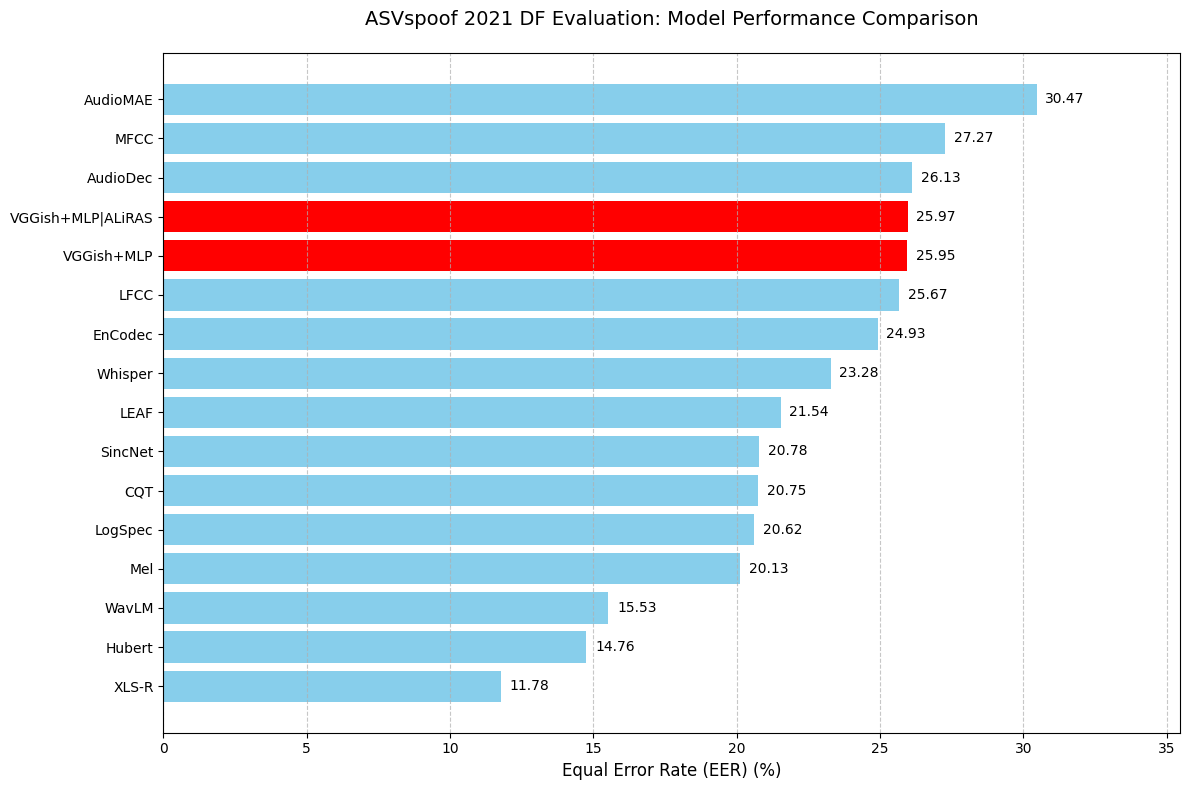

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['Mel', 'MFCC', 'LogSpec', 'LFCC', 'CQT', 'LEAF', 'SincNet',
          'EnCodec', 'AudioDec', 'AudioMAE', 'XLS-R', 'Hubert', 'WavLM',
          'Whisper', 'VGGish+MLP', 'VGGish+MLP|ALiRAS']
eer = [20.13, 27.27, 20.62, 25.67, 20.75, 21.54, 20.78,
       24.93, 26.13, 30.47, 11.78, 14.76, 15.53, 23.28, 25.95, 25.97]

sorted_indices = np.argsort(eer)
models = [models[i] for i in sorted_indices]
eer = [eer[i] for i in sorted_indices]

colors = ['red' if ('VGGish' in model) else 'skyblue' for model in models]

plt.figure(figsize=(12, 8))
bars = plt.barh(models, eer, color=colors)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}',
             ha='left', va='center')

plt.xlabel('Equal Error Rate (EER) (%)', fontsize=12)
plt.title('ASVspoof 2021 DF Evaluation: Model Performance Comparison', fontsize=14, pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlim(0, max(eer) + 5)
plt.tight_layout()

# Show plot
plt.show()

In [ ]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


# ALiRAS + SSL models


In [106]:
y_train_aliras = y_train_pred 

In [107]:
y_test_aliras = y_test_pred

In [27]:
y_test_aliras

0       0.721475
1       0.641497
2       0.520250
3       0.517352
4       0.624402
          ...   
6995    0.760947
6996    0.547131
6997    0.693984
6998    0.527357
6999    0.625051
Name: y_test_pred, Length: 7000, dtype: float64

In [28]:
y_test_aliras.shape

(7000,)

In [29]:
y_train_xlsr = pd.read_csv('asvspoof5_train_predictions_xlsr_resnet18_7000_df.csv')

In [30]:
y_test_xlsr = pd.read_csv('asvspoof5_test_predictions_xlsr_resnet18_7000_df.csv')

In [31]:
y_train_xlsr

,audio_filenames,prob_spoof
0,T_0000000000.flac,0.044045
1,T_0000000001.flac,0.176716
2,T_0000000002.flac,0.093619
3,T_0000000003.flac,0.130889
4,T_0000000004.flac,0.145528
...,...,...
6996,T_0000006996.flac,0.195978
6997,T_0000006997.flac,0.020163
6998,T_0000006998.flac,0.047112
6999,T_0000006999.flac,0.244248


In [100]:
y_train_hubert = pd.read_csv('asvspoof5_train_predictions_hubert_resnet18_7000_df.csv')

In [97]:
y_test_hubert = pd.read_csv('asvspoof5_test_predictions_hubert_resnet18_7000_df.csv')


In [98]:
y_test_hubert

,audio_filenames,prob_spoof
0,E_0000000024,0.003437
1,E_0000000034,0.915246
2,E_0000000076,0.033081
3,E_0000000111,0.977017
4,E_0000000146,0.000793
...,...,...
6995,E_0000106133,0.015859
6996,E_0000106138,0.995039
6997,E_0000106142,0.999999
6998,E_0000106158,0.005510


In [35]:
y_test

0       1
1       1
2       1
3       1
4       1
       ..
6995    1
6996    0
6997    0
6998    1
6999    1
Name: true_label_fake1_real0, Length: 7000, dtype: int64

In [101]:
y_train_hubert

,audio_filenames,prob_spoof
0,T_0000000000,1.000000
1,T_0000000001,1.000000
2,T_0000000002,1.000000
3,T_0000000003,1.000000
4,T_0000000004,1.000000
...,...,...
6995,T_0000006995,1.000000
6996,T_0000006996,1.000000
6997,T_0000006997,1.000000
6998,T_0000006998,0.000001


In [99]:
y_test_xlsr

,audio_filenames,prob_spoof,prob_spoof_hubert,prob_spoof_aliras,y_true
0,E_0000000024,0.315902,1.0,0.721475,1
1,E_0000000034,0.116478,1.0,0.641497,1
2,E_0000000076,0.218408,1.0,0.520250,1
3,E_0000000111,0.494793,1.0,0.517352,1
4,E_0000000146,0.176086,1.0,0.624402,1
...,...,...,...,...,...
6995,E_0000106133,0.113229,1.0,0.760947,1
6996,E_0000106138,0.213950,1.0,0.547131,0
6997,E_0000106142,0.197099,1.0,0.693984,0
6998,E_0000106158,0.166105,1.0,0.527357,1


In [38]:
y_train_xlsr = y_train_xlsr.iloc[:7000,:]

In [105]:
df_train = y_train_xlsr

In [106]:
y_train_hubert = y_train_hubert.rename(columns={'prob_spoof': 'prob_spoof_hubert'})

In [107]:
y_test_hubert = y_test_hubert.rename(columns={'prob_spoof': 'prob_spoof_hubert'})

In [108]:
df_test = y_test_xlsr

In [110]:
df_test.drop(columns=["prob_spoof_hubert"], inplace=True)


In [111]:
df_test

,audio_filenames,prob_spoof,prob_spoof_aliras,y_true
0,E_0000000024,0.315902,0.721475,1
1,E_0000000034,0.116478,0.641497,1
2,E_0000000076,0.218408,0.520250,1
3,E_0000000111,0.494793,0.517352,1
4,E_0000000146,0.176086,0.624402,1
...,...,...,...,...
6995,E_0000106133,0.113229,0.760947,1
6996,E_0000106138,0.213950,0.547131,0
6997,E_0000106142,0.197099,0.693984,0
6998,E_0000106158,0.166105,0.527357,1


In [112]:
df_train['prob_spoof_hubert'] = y_train_hubert['prob_spoof_hubert']

In [113]:
df_test['prob_spoof_hubert'] = y_test_hubert['prob_spoof_hubert']

In [114]:
df_train

,audio_filenames,prob_spoof,prob_spoof_aliras,y_true,prob_spoof_hubert
0,T_0000000000.flac,0.044045,0.689496,1,1.000000
1,T_0000000001.flac,0.176716,0.716402,1,1.000000
2,T_0000000002.flac,0.093619,0.395948,1,1.000000
3,T_0000000003.flac,0.130889,0.472303,1,1.000000
4,T_0000000004.flac,0.145528,0.399888,1,1.000000
...,...,...,...,...,...
6995,T_0000006995.flac,0.161747,0.453467,1,1.000000
6996,T_0000006996.flac,0.195978,0.428176,1,1.000000
6997,T_0000006997.flac,0.020163,0.406310,1,1.000000
6998,T_0000006998.flac,0.047112,0.411814,0,0.000001


In [115]:
y_train_xlsr.shape

(7000, 5)

In [51]:
df_train['prob_spoof_aliras'] = y_train_aliras

In [52]:
df_test['prob_spoof_aliras'] = y_test_aliras

In [53]:
y_train_aliras

0       0.689496
1       0.716402
2       0.395948
3       0.472303
4       0.399888
          ...   
6995    0.453467
6996    0.428176
6997    0.406310
6998    0.411814
6999    0.438849
Name: y_train_pred, Length: 7000, dtype: float64

In [116]:
df_train

,audio_filenames,prob_spoof,prob_spoof_aliras,y_true,prob_spoof_hubert
0,T_0000000000.flac,0.044045,0.689496,1,1.000000
1,T_0000000001.flac,0.176716,0.716402,1,1.000000
2,T_0000000002.flac,0.093619,0.395948,1,1.000000
3,T_0000000003.flac,0.130889,0.472303,1,1.000000
4,T_0000000004.flac,0.145528,0.399888,1,1.000000
...,...,...,...,...,...
6995,T_0000006995.flac,0.161747,0.453467,1,1.000000
6996,T_0000006996.flac,0.195978,0.428176,1,1.000000
6997,T_0000006997.flac,0.020163,0.406310,1,1.000000
6998,T_0000006998.flac,0.047112,0.411814,0,0.000001


In [117]:
df_test

,audio_filenames,prob_spoof,prob_spoof_aliras,y_true,prob_spoof_hubert
0,E_0000000024,0.315902,0.721475,1,0.003437
1,E_0000000034,0.116478,0.641497,1,0.915246
2,E_0000000076,0.218408,0.520250,1,0.033081
3,E_0000000111,0.494793,0.517352,1,0.977017
4,E_0000000146,0.176086,0.624402,1,0.000793
...,...,...,...,...,...
6995,E_0000106133,0.113229,0.760947,1,0.015859
6996,E_0000106138,0.213950,0.547131,0,0.995039
6997,E_0000106142,0.197099,0.693984,0,0.999999
6998,E_0000106158,0.166105,0.527357,1,0.005510


In [118]:
y_test_hubert

,audio_filenames,prob_spoof_hubert
0,E_0000000024,0.003437
1,E_0000000034,0.915246
2,E_0000000076,0.033081
3,E_0000000111,0.977017
4,E_0000000146,0.000793
...,...,...
6995,E_0000106133,0.015859
6996,E_0000106138,0.995039
6997,E_0000106142,0.999999
6998,E_0000106158,0.005510


In [5]:
df_test

,audio_filenames,prob_spoof,prob_spoof_aliras,y_true,prob_spoof_hubert
0,E_0000000024,0.315902,0.721475,1,0.003437
1,E_0000000034,0.116478,0.641497,1,0.915246
2,E_0000000076,0.218408,0.520250,1,0.033081
3,E_0000000111,0.494793,0.517352,1,0.977017
4,E_0000000146,0.176086,0.624402,1,0.000793
...,...,...,...,...,...
6995,E_0000106133,0.113229,0.760947,1,0.015859
6996,E_0000106138,0.213950,0.547131,0,0.995039
6997,E_0000106142,0.197099,0.693984,0,0.999999
6998,E_0000106158,0.166105,0.527357,1,0.005510


In [58]:
df_test['y_true'] = y_test
df_train['y_true']=y_train

In [59]:
df_test

,audio_filenames,prob_spoof,prob_spoof_hubert,prob_spoof_aliras,y_true
0,E_0000000024,0.315902,1.0,0.721475,1
1,E_0000000034,0.116478,1.0,0.641497,1
2,E_0000000076,0.218408,1.0,0.520250,1
3,E_0000000111,0.494793,1.0,0.517352,1
4,E_0000000146,0.176086,1.0,0.624402,1
...,...,...,...,...,...
6995,E_0000106133,0.113229,1.0,0.760947,1
6996,E_0000106138,0.213950,1.0,0.547131,0
6997,E_0000106142,0.197099,1.0,0.693984,0
6998,E_0000106158,0.166105,1.0,0.527357,1


In [60]:
df_test = df_test.rename(columns={'prob_spoof': 'prob_spoof_xlsr'})

In [61]:
df_train = df_train.rename(columns={'prob_spoof': 'prob_spoof_xlsr'})

In [62]:
df_test

,audio_filenames,prob_spoof_xlsr,prob_spoof_hubert,prob_spoof_aliras,y_true
0,E_0000000024,0.315902,1.0,0.721475,1
1,E_0000000034,0.116478,1.0,0.641497,1
2,E_0000000076,0.218408,1.0,0.520250,1
3,E_0000000111,0.494793,1.0,0.517352,1
4,E_0000000146,0.176086,1.0,0.624402,1
...,...,...,...,...,...
6995,E_0000106133,0.113229,1.0,0.760947,1
6996,E_0000106138,0.213950,1.0,0.547131,0
6997,E_0000106142,0.197099,1.0,0.693984,0
6998,E_0000106158,0.166105,1.0,0.527357,1


In [120]:
df_test.to_csv('asvspoof5_outputs_for_ensemble_7000samples_test.csv', index=False)

In [3]:
import pandas as pd
df_test = pd.read_csv('asvspoof5_outputs_for_ensemble_7000samples_test.csv')

In [4]:
df_test

,audio_filenames,prob_spoof,prob_spoof_aliras,y_true,prob_spoof_hubert
0,E_0000000024,0.315902,0.721475,1,0.003437
1,E_0000000034,0.116478,0.641497,1,0.915246
2,E_0000000076,0.218408,0.520250,1,0.033081
3,E_0000000111,0.494793,0.517352,1,0.977017
4,E_0000000146,0.176086,0.624402,1,0.000793
...,...,...,...,...,...
6995,E_0000106133,0.113229,0.760947,1,0.015859
6996,E_0000106138,0.213950,0.547131,0,0.995039
6997,E_0000106142,0.197099,0.693984,0,0.999999
6998,E_0000106158,0.166105,0.527357,1,0.005510


In [8]:
roc_auc = roc_auc_score(df_test['y_true'], df_test['prob_spoof_hubert'])

print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.6654282815905705


In [121]:
df_train.to_csv('asvspoof5_outputs_for_ensemble_7000samples_train.csv', index=False)

In [62]:
df_train = pd.read_csv('asvspoof5_outputs_for_ensemble_7000samples_train.csv')

In [63]:
df_test = pd.read_csv('asvspoof5_outputs_for_ensemble_7000samples_test.csv')

In [10]:
df_train

,audio_filenames,prob_spoof,prob_spoof_aliras,y_true,prob_spoof_hubert
0,T_0000000000.flac,0.044045,0.689496,1,1.000000
1,T_0000000001.flac,0.176716,0.716402,1,1.000000
2,T_0000000002.flac,0.093619,0.395948,1,1.000000
3,T_0000000003.flac,0.130889,0.472303,1,1.000000
4,T_0000000004.flac,0.145528,0.399888,1,1.000000
...,...,...,...,...,...
6995,T_0000006995.flac,0.161747,0.453467,1,1.000000
6996,T_0000006996.flac,0.195978,0.428176,1,1.000000
6997,T_0000006997.flac,0.020163,0.406310,1,1.000000
6998,T_0000006998.flac,0.047112,0.411814,0,0.000001


In [64]:
y_train_aliras

0       0.689496
1       0.716402
2       0.395948
3       0.472303
4       0.399888
          ...   
6995    0.453467
6996    0.428176
6997    0.406310
6998    0.411814
6999    0.438849
Name: y_train_pred, Length: 7000, dtype: float64

In [64]:
train_probs_aliras = df_train['prob_spoof_aliras']
test_probs_aliras = df_test['prob_spoof_aliras']

In [65]:
train_probs_hubert = df_train['prob_spoof_hubert']
test_probs_hubert = df_test['prob_spoof_hubert']

In [66]:
train_probs_xlsr = df_train['prob_spoof']
test_probs_xlsr = df_test['prob_spoof']

In [67]:
y_train = df_train['y_true']

In [68]:
y_test = df_test['y_true']

In [69]:
# Step 1: Determine the weights
weight1 = 0.6
weight2 = 0.4

# Step 2: Combine the predictions
ensemble_prediction_hubert = (weight1 * train_probs_hubert) + (weight2 * train_probs_aliras)

roc_auc = roc_auc_score(y_train, ensemble_prediction_hubert)

print("ROC AUC Score:", roc_auc)


ROC AUC Score: 0.9969798121234555


In [70]:
#test_probs is from vggish only
ensemble_prediction_test_hubert = (weight1 * test_probs_hubert) + (weight2 * test_probs_aliras)

roc_auc = roc_auc_score(y_test, ensemble_prediction_test_hubert)

print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.64949849208078


In [71]:
pwd&&

'/umbc/rs/iharp/users/zkhanja1/asvspoof5_codes'

In [72]:
compute_eer(y_train, ensemble_prediction_hubert)

(np.float64(0.006791345447132234), np.float64(0.7540317519999999))

In [73]:
compute_eer_fixed_threshold(y_test, ensemble_prediction_test_hubert, 0.7540317519999999)

np.float64(0.40086221238919445)

In [79]:
#df_train_final['prob_spoof_from_aliras_hubert'] =  ensemble_prediction_hubert

In [ ]:
#df_test_final['prob_spoof_from_aliras_hubert'] =  ensemble_prediction_test_hubert

In [74]:
weight1 = 0.6
weight2 = 0.4

# Step 2: Combine the predictions
ensemble_prediction_xlsr = (weight1 * train_probs_xlsr) + (weight2 * train_probs_aliras)

roc_auc = roc_auc_score(y_train, ensemble_prediction_xlsr)

print("ROC AUC Score for train:", roc_auc)
ensemble_prediction_test_xlsr = (weight1 * test_probs_xlsr) + (weight2 * test_probs_aliras)

roc_auc = roc_auc_score(y_test, ensemble_prediction_test_xlsr)

print("ROC AUC Score for test:", roc_auc)
compute_eer(y_train, ensemble_prediction_xlsr)


ROC AUC Score for train: 0.8952013691060574
ROC AUC Score for test: 0.6871627653485717


(np.float64(0.1837928315066068), np.float64(0.23462375800000002))

In [75]:
compute_eer_fixed_threshold(y_test, ensemble_prediction_test_xlsr, 0.23462375800000002)

np.float64(0.4875380350527979)

In [76]:
train_probs_xlsr

0       0.044045
1       0.176716
2       0.093619
3       0.130889
4       0.145528
          ...   
6995    0.161747
6996    0.195978
6997    0.020163
6998    0.047112
6999    0.244248
Name: prob_spoof, Length: 7000, dtype: float64

In [77]:
compute_eer(y_train, train_probs_xlsr)


(np.float64(0.18649402625550565), np.float64(0.0841032))

In [78]:
compute_eer_fixed_threshold(y_test, test_probs_xlsr, 0.0841032)

np.float64(0.4389722869669047)

In [79]:
ensemble_prediction_test_hubert

0       0.290652
1       0.805746
2       0.227948
3       0.793151
4       0.250236
          ...   
6995    0.313894
6996    0.815875
6997    0.877593
6998    0.214249
6999    0.383575
Length: 7000, dtype: float64

In [80]:
weight1 = 0.5
weight2 = 0.5

# Step 2: Combine the predictions
ensemble_prediction_ssl = (weight1 * train_probs_xlsr) + (weight2 * train_probs_hubert)

roc_auc = roc_auc_score(y_train, ensemble_prediction_ssl)

print("ROC AUC Score for train:", roc_auc)
ensemble_prediction_test_ssl = (weight1 * test_probs_xlsr) + (weight2 * test_probs_hubert)

roc_auc = roc_auc_score(y_test, ensemble_prediction_test_ssl)

print("ROC AUC Score for test:", roc_auc)
compute_eer(y_train, ensemble_prediction_ssl)

ROC AUC Score for train: 0.9988019249030305
ROC AUC Score for test: 0.6669444266115674


(np.float64(0.013585909795653394), np.float64(0.518071415))

In [81]:
compute_eer_fixed_threshold(y_test, ensemble_prediction_test_ssl, 0.493465485)

np.float64(0.4005905135608825)

In [82]:
df_train

,audio_filenames,prob_spoof,prob_spoof_aliras,y_true,prob_spoof_hubert
0,T_0000000000.flac,0.044045,0.689496,1,1.000000
1,T_0000000001.flac,0.176716,0.716402,1,1.000000
2,T_0000000002.flac,0.093619,0.395948,1,1.000000
3,T_0000000003.flac,0.130889,0.472303,1,1.000000
4,T_0000000004.flac,0.145528,0.399888,1,1.000000
...,...,...,...,...,...
6995,T_0000006995.flac,0.161747,0.453467,1,1.000000
6996,T_0000006996.flac,0.195978,0.428176,1,1.000000
6997,T_0000006997.flac,0.020163,0.406310,1,1.000000
6998,T_0000006998.flac,0.047112,0.411814,0,0.000001


In [97]:
cost_efficient_hubert_aliras_train = df_train.apply(
    lambda row: 1 if row['prob_spoof_aliras'] > 0.7 else row['prob_spoof_hubert'],
    axis=1
)


roc_auc = roc_auc_score(y_train, cost_efficient_hubert_aliras_train)

print("ROC AUC Score for train:", roc_auc)
compute_eer(y_train, cost_efficient_hubert_aliras_train)

ROC AUC Score for train: 0.9897807391670557


(np.float64(0.017421230800594448), np.float64(1.0))

In [99]:
cost_efficient_hubert_aliras_test = df_test.apply(
    lambda row: 1 if row['prob_spoof_aliras'] > 0.7 else row['prob_spoof_hubert'],
    axis=1
)


roc_auc = roc_auc_score(y_test, cost_efficient_hubert_aliras_test)
print("ROC AUC Score for test:", roc_auc)

compute_eer_fixed_threshold(y_test, cost_efficient_hubert_aliras_test, 0.9999)

ROC AUC Score for test: 0.6378329454837198


np.float64(0.3777632352211732)

In [85]:
df_train

,audio_filenames,prob_spoof,prob_spoof_aliras,y_true,prob_spoof_hubert
0,T_0000000000.flac,0.044045,0.689496,1,1.000000
1,T_0000000001.flac,0.176716,0.716402,1,1.000000
2,T_0000000002.flac,0.093619,0.395948,1,1.000000
3,T_0000000003.flac,0.130889,0.472303,1,1.000000
4,T_0000000004.flac,0.145528,0.399888,1,1.000000
...,...,...,...,...,...
6995,T_0000006995.flac,0.161747,0.453467,1,1.000000
6996,T_0000006996.flac,0.195978,0.428176,1,1.000000
6997,T_0000006997.flac,0.020163,0.406310,1,1.000000
6998,T_0000006998.flac,0.047112,0.411814,0,0.000001


In [100]:
cost_efficient_xlsr_aliras_train = df_train.apply(
    lambda row: 1 if row['prob_spoof_aliras'] > 0.7 else row['prob_spoof'],
    axis=1
)


roc_auc = roc_auc_score(y_train, cost_efficient_xlsr_aliras_train)

print("ROC AUC Score for train:", roc_auc)
compute_eer(y_train, cost_efficient_xlsr_aliras_train)

ROC AUC Score for train: 0.9003032205108397


(np.float64(0.169455844720197), np.float64(0.08815601))

In [101]:


cost_efficient_xlsr_aliras_test = df_test.apply(
    lambda row: 1 if row['prob_spoof_aliras'] > 0.7 else row['prob_spoof'],
    axis=1
)


roc_auc = roc_auc_score(y_test, cost_efficient_xlsr_aliras_test)
print("ROC AUC Score for test:", roc_auc)

compute_eer_fixed_threshold(y_test, cost_efficient_xlsr_aliras_test, 0.08815601)

ROC AUC Score for test: 0.6366777461403985


np.float64(0.45066597446241297)

In [88]:
df_test_final = df_test

In [89]:

df_test_final['prob_spoof_from_aliras_xlsr']= ensemble_prediction_test_xlsr
df_test_final['prob_spoof_from_aliras_hubert']= ensemble_prediction_test_hubert
df_test_final['cost_efficient_xlsr_aliras']=cost_efficient_xlsr_aliras_test
df_test_final['prob_spoof_from_aliras_hubert_cost_efficient']=cost_efficient_hubert_aliras_test

In [90]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

For the chart below the threshold for the cost efficient ensemble is chosen as 0.75, in this way we see 0.69 roc auc but only 0.14 % time reduction while in the second plot after this, we have 0.7 threshold 0.63 performance for 0.42 % time reduction. Therefore, the usage of the threshold which will be done using validation set is dependent on the resources available and primary goals of the stake holders. 

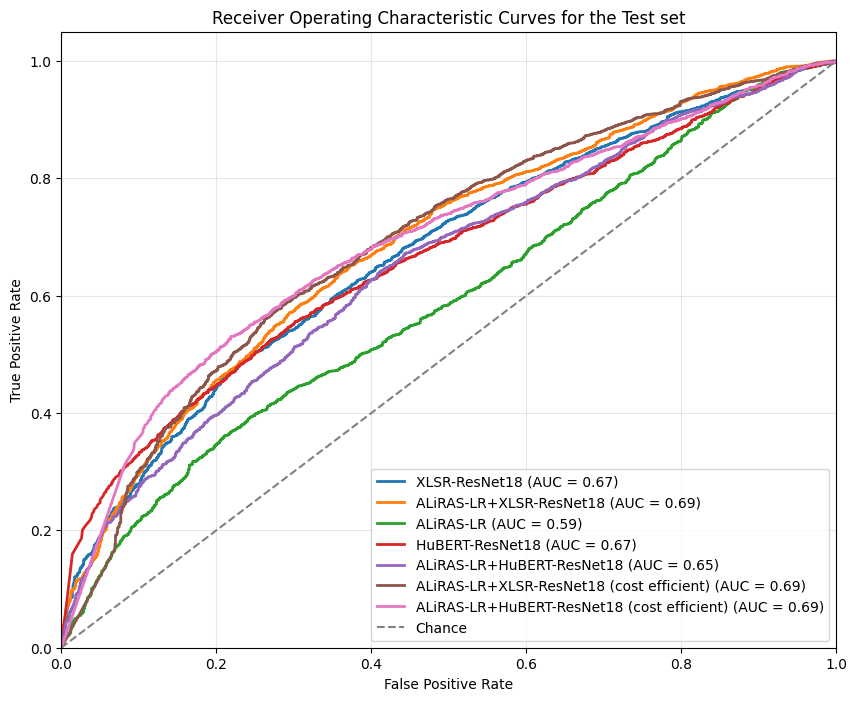

In [91]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# True labels
y_true = df_test_final['y_true']

# Dictionary of models and their predicted probabilities
model_preds = {
    'XLSR-ResNet18': df_test_final['prob_spoof'],
    'ALiRAS-LR+XLSR-ResNet18': df_test_final['prob_spoof_from_aliras_xlsr'],
    'ALiRAS-LR': df_test_final['prob_spoof_aliras'],
    'HuBERT-ResNet18': df_test_final['prob_spoof_hubert'],
    'ALiRAS-LR+HuBERT-ResNet18': df_test_final['prob_spoof_from_aliras_hubert'],
    'ALiRAS-LR+XLSR-ResNet18 (cost efficient)': df_test_final['cost_efficient_xlsr_aliras'],
    'ALiRAS-LR+HuBERT-ResNet18 (cost efficient)': df_test_final['prob_spoof_from_aliras_hubert_cost_efficient'],

}

plt.figure(figsize=(10, 8))

# Plot ROC for each model
for model_name, y_pred in model_preds.items():
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

# Plot chance line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Chance')

# Graph formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curves for the Test set')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


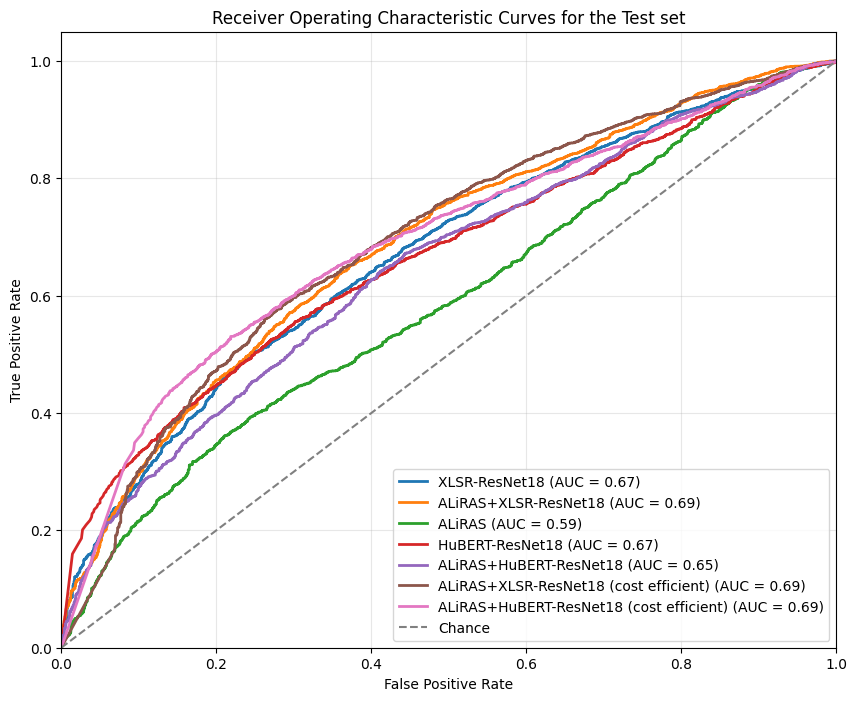

In [106]:
#same as above just removed the classifier name for AliRAS
# True labels
y_true = df_test_final['y_true']

# Dictionary of models and their predicted probabilities
model_preds = {
    'XLSR-ResNet18': df_test_final['prob_spoof'],
    'ALiRAS+XLSR-ResNet18': df_test_final['prob_spoof_from_aliras_xlsr'],
    'ALiRAS': df_test_final['prob_spoof_aliras'],
    'HuBERT-ResNet18': df_test_final['prob_spoof_hubert'],
    'ALiRAS+HuBERT-ResNet18': df_test_final['prob_spoof_from_aliras_hubert'],
    'ALiRAS+XLSR-ResNet18 (cost efficient)': df_test_final['cost_efficient_xlsr_aliras'],
    'ALiRAS+HuBERT-ResNet18 (cost efficient)': df_test_final['prob_spoof_from_aliras_hubert_cost_efficient'],

}

plt.figure(figsize=(10, 8))

# Plot ROC for each model
for model_name, y_pred in model_preds.items():
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

# Plot chance line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Chance')

# Graph formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curves for the Test set')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


In [102]:
df_test_final['cost_efficient_xlsr_aliras_0.7']=cost_efficient_xlsr_aliras_test
df_test_final['prob_spoof_from_aliras_hubert_cost_efficient_0.7']=cost_efficient_hubert_aliras_test

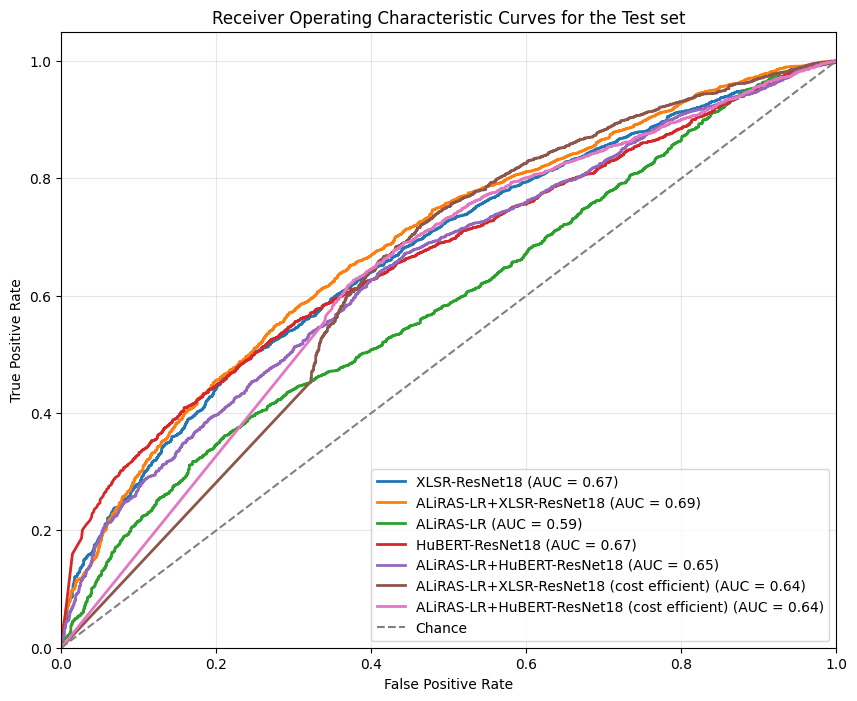

In [103]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# True labels
y_true = df_test_final['y_true']

# Dictionary of models and their predicted probabilities
model_preds = {
    'XLSR-ResNet18': df_test_final['prob_spoof'],
    'ALiRAS-LR+XLSR-ResNet18': df_test_final['prob_spoof_from_aliras_xlsr'],
    'ALiRAS-LR': df_test_final['prob_spoof_aliras'],
    'HuBERT-ResNet18': df_test_final['prob_spoof_hubert'],
    'ALiRAS-LR+HuBERT-ResNet18': df_test_final['prob_spoof_from_aliras_hubert'],
    'ALiRAS-LR+XLSR-ResNet18 (cost efficient)': df_test_final['cost_efficient_xlsr_aliras_0.7'],
    'ALiRAS-LR+HuBERT-ResNet18 (cost efficient)': df_test_final['prob_spoof_from_aliras_hubert_cost_efficient_0.7'],

}

plt.figure(figsize=(10, 8))

# Plot ROC for each model
for model_name, y_pred in model_preds.items():
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

# Plot chance line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Chance')

# Graph formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curves for the Test set')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


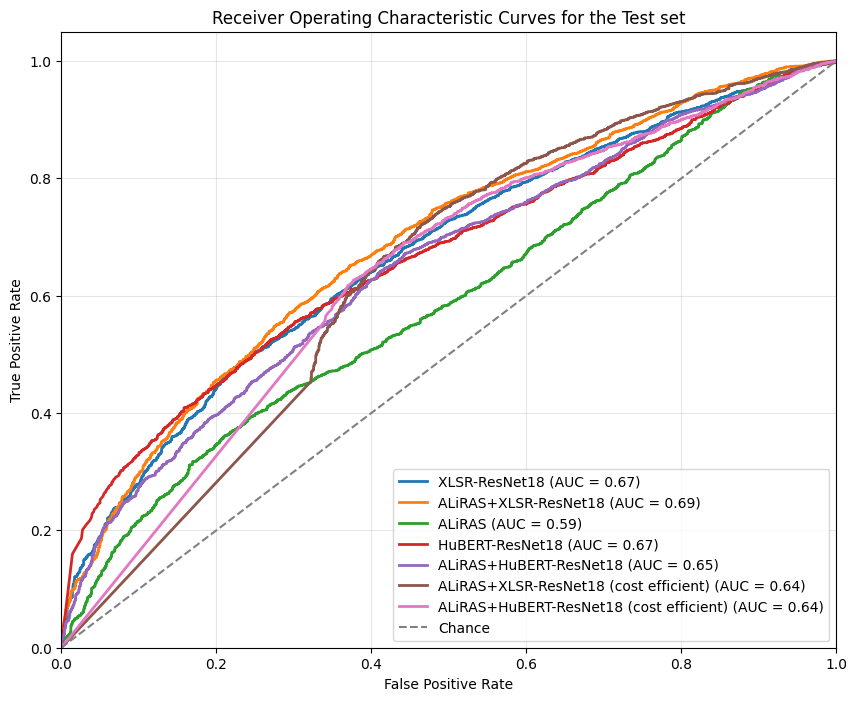

In [107]:
#same as above just removed the classifier name for AliRAS

# True labels
y_true = df_test_final['y_true']

# Dictionary of models and their predicted probabilities
model_preds = {
    'XLSR-ResNet18': df_test_final['prob_spoof'],
    'ALiRAS+XLSR-ResNet18': df_test_final['prob_spoof_from_aliras_xlsr'],
    'ALiRAS': df_test_final['prob_spoof_aliras'],
    'HuBERT-ResNet18': df_test_final['prob_spoof_hubert'],
    'ALiRAS+HuBERT-ResNet18': df_test_final['prob_spoof_from_aliras_hubert'],
    'ALiRAS+XLSR-ResNet18 (cost efficient)': df_test_final['cost_efficient_xlsr_aliras_0.7'],
    'ALiRAS+HuBERT-ResNet18 (cost efficient)': df_test_final['prob_spoof_from_aliras_hubert_cost_efficient_0.7'],

}

plt.figure(figsize=(10, 8))

# Plot ROC for each model
for model_name, y_pred in model_preds.items():
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

# Plot chance line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Chance')

# Graph formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curves for the Test set')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


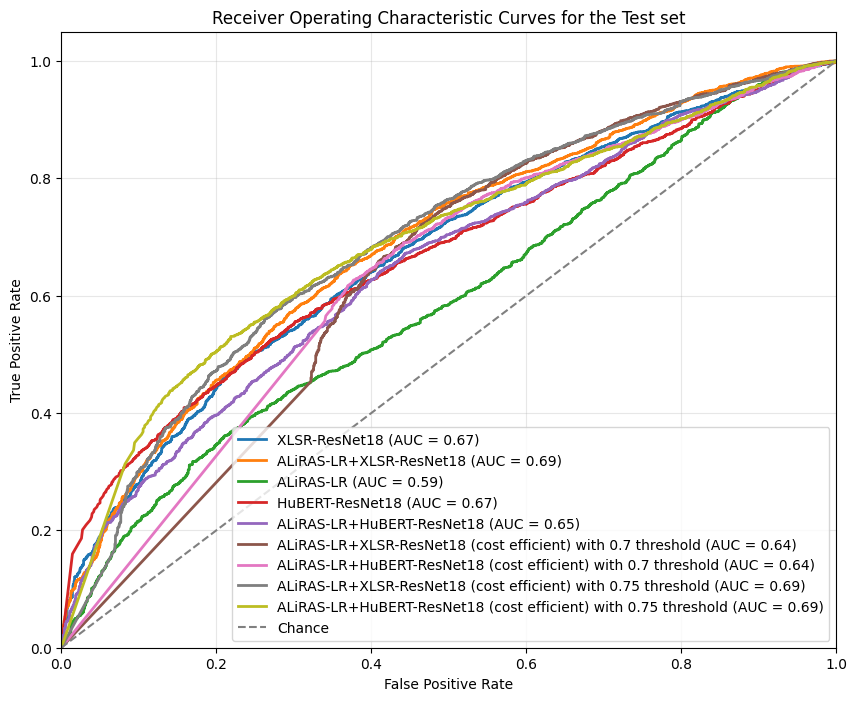

In [104]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# True labels
y_true = df_test_final['y_true']

# Dictionary of models and their predicted probabilities
model_preds = {
    'XLSR-ResNet18': df_test_final['prob_spoof'],
    'ALiRAS-LR+XLSR-ResNet18': df_test_final['prob_spoof_from_aliras_xlsr'],
    'ALiRAS-LR': df_test_final['prob_spoof_aliras'],
    'HuBERT-ResNet18': df_test_final['prob_spoof_hubert'],
    'ALiRAS-LR+HuBERT-ResNet18': df_test_final['prob_spoof_from_aliras_hubert'],
    'ALiRAS-LR+XLSR-ResNet18 (cost efficient) with 0.7 threshold': df_test_final['cost_efficient_xlsr_aliras_0.7'],
    'ALiRAS-LR+HuBERT-ResNet18 (cost efficient) with 0.7 threshold': df_test_final['prob_spoof_from_aliras_hubert_cost_efficient_0.7'],
    'ALiRAS-LR+XLSR-ResNet18 (cost efficient) with 0.75 threshold': df_test_final['cost_efficient_xlsr_aliras'],
    'ALiRAS-LR+HuBERT-ResNet18 (cost efficient) with 0.75 threshold': df_test_final['prob_spoof_from_aliras_hubert_cost_efficient'],

    
}

plt.figure(figsize=(10, 8))

# Plot ROC for each model
for model_name, y_pred in model_preds.items():
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

# Plot chance line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Chance')

# Graph formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curves for the Test set')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


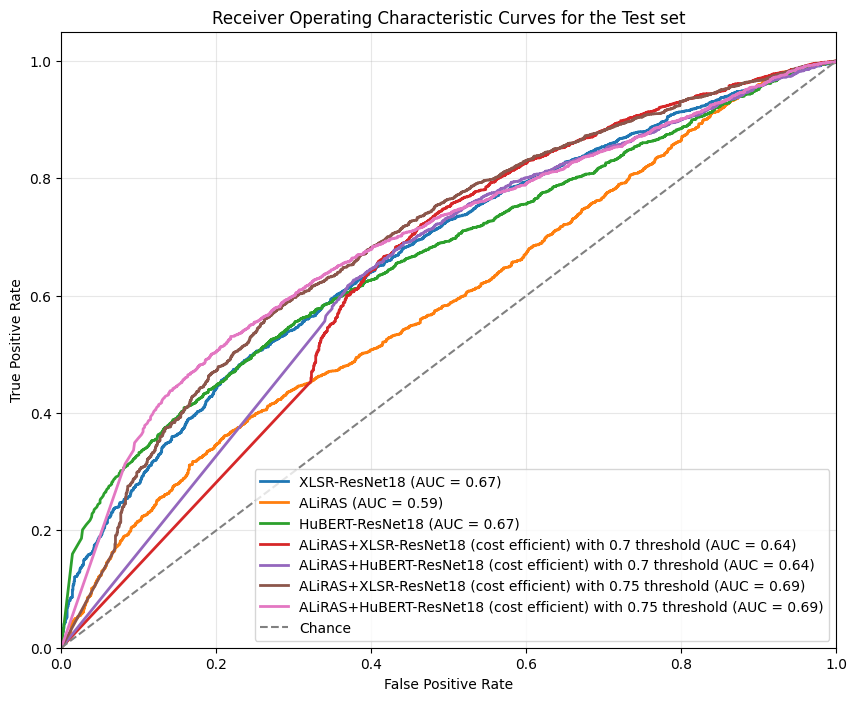

In [108]:
#same as above just removed the classifier name for AliRAS

# True labels
y_true = df_test_final['y_true']

# Dictionary of models and their predicted probabilities
model_preds = {
    'XLSR-ResNet18': df_test_final['prob_spoof'],
    'ALiRAS': df_test_final['prob_spoof_aliras'],
    'HuBERT-ResNet18': df_test_final['prob_spoof_hubert'],
    'ALiRAS+XLSR-ResNet18 (cost efficient) with 0.7 threshold': df_test_final['cost_efficient_xlsr_aliras_0.7'],
    'ALiRAS+HuBERT-ResNet18 (cost efficient) with 0.7 threshold': df_test_final['prob_spoof_from_aliras_hubert_cost_efficient_0.7'],
    'ALiRAS+XLSR-ResNet18 (cost efficient) with 0.75 threshold': df_test_final['cost_efficient_xlsr_aliras'],
    'ALiRAS+HuBERT-ResNet18 (cost efficient) with 0.75 threshold': df_test_final['prob_spoof_from_aliras_hubert_cost_efficient'],

    
}

plt.figure(figsize=(10, 8))

# Plot ROC for each model
for model_name, y_pred in model_preds.items():
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

# Plot chance line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Chance')

# Graph formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curves for the Test set')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


In [92]:
df_test

,audio_filenames,prob_spoof,prob_spoof_aliras,y_true,prob_spoof_hubert,prob_spoof_from_aliras_xlsr,prob_spoof_from_aliras_hubert,cost_efficient_xlsr_aliras,prob_spoof_from_aliras_hubert_cost_efficient
0,E_0000000024,0.315902,0.721475,1,0.003437,0.478131,0.290652,0.315902,0.003437
1,E_0000000034,0.116478,0.641497,1,0.915246,0.326486,0.805746,0.116478,0.915246
2,E_0000000076,0.218408,0.520250,1,0.033081,0.339145,0.227948,0.218408,0.033081
3,E_0000000111,0.494793,0.517352,1,0.977017,0.503817,0.793151,0.494793,0.977017
4,E_0000000146,0.176086,0.624402,1,0.000793,0.355412,0.250236,0.176086,0.000793
...,...,...,...,...,...,...,...,...,...
6995,E_0000106133,0.113229,0.760947,1,0.015859,0.372317,0.313894,1.000000,1.000000
6996,E_0000106138,0.213950,0.547131,0,0.995039,0.347222,0.815875,0.213950,0.995039
6997,E_0000106142,0.197099,0.693984,0,0.999999,0.395853,0.877593,0.197099,0.999999
6998,E_0000106158,0.166105,0.527357,1,0.005510,0.310606,0.214249,0.166105,0.005510


In [93]:
# how much cost efficient is really efficient?
count = (df_test['prob_spoof_aliras'] <= 0.75).sum()
print(f'Number of rows with prob_spoof_from_aliras_lr which will be hubert for them < 0.75: {count}')

Number of rows with prob_spoof_from_aliras_lr which will be hubert for them < 0.75: 5965


In [94]:
count = (df_test['prob_spoof_aliras'] <= 0.70).sum()
print(f'Number of rows with prob_spoof_from_aliras_lr which will be hubert for them < 0.70: {count}')

Number of rows with prob_spoof_from_aliras_lr which will be hubert for them < 0.70: 4015


In [95]:
(7000-4015)/7000

0.42642857142857143

In [96]:
(7000-5965)/7000

0.14785714285714285